In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
sid321axn_gold_price_prediction_dataset_path = kagglehub.dataset_download('sid321axn/gold-price-prediction-dataset')

print('Data source import complete.')


# Prediksi Harga Emas Menggunakan Pendekatan Machine Learning

## Pendahuluan

Emas telah lama digunakan sebagai alat tukar dan simbol kekayaan di berbagai belahan dunia. Saat ini, emas memiliki peran penting dalam ekonomi global, terutama sebagai aset lindung nilai terhadap inflasi dan ketidakstabilan pasar. Bank sentral banyak negara menyimpan emas sebagai cadangan devisa untuk menjamin stabilitas ekonomi dan kepercayaan pasar.

Fluktuasi harga emas dipengaruhi oleh berbagai faktor seperti nilai tukar mata uang, inflasi, suku bunga, dan kondisi geopolitik. Oleh karena itu, melakukan prediksi terhadap pergerakan harga emas dapat membantu investor dan pembuat kebijakan dalam mengambil keputusan yang lebih tepat.

Dalam proyek ini, kita akan menggunakan berbagai algoritma machine learning untuk melakukan prediksi harga emas berdasarkan faktor-faktor ekonomi yang relevan. Selain itu, kita juga akan menganalisis fitur-fitur yang memiliki pengaruh paling signifikan terhadap perubahan harga emas.

---

## Alur Proyek

Proses pengerjaan proyek ini dilakukan melalui beberapa tahapan utama:

1. **Pengumpulan Data**  
   - Menggunakan dataset yang berisi harga emas historis serta faktor-faktor ekonomi yang berpengaruh.  
   - Data diperoleh dari sumber terpercaya seperti pasar keuangan atau repository publik.

2. **Eksplorasi dan Pemahaman Data**  
   - Melakukan analisis eksplorasi data (EDA) untuk memahami pola dalam dataset.  
   - Visualisasi data untuk mengidentifikasi tren historis.

3. **Preprocessing Data**  
   - Menangani nilai yang hilang dan data yang tidak konsisten.  
   - Normalisasi dan transformasi fitur untuk meningkatkan akurasi model.

4. **Pemodelan Machine Learning**  
   - Menerapkan berbagai algoritma seperti Regresi Linier, Random Forest, dan LSTM.  
   - Melakukan tuning hyperparameter untuk meningkatkan kinerja model.

5. **Evaluasi Model**  
   - Menggunakan metrik evaluasi seperti Mean Absolute Error (MAE) dan Root Mean Squared Error (RMSE) untuk menilai performa model.  
   - Membandingkan hasil prediksi dengan data aktual.

6. **Kesimpulan dan Interpretasi**  
   - Menentukan faktor utama yang mempengaruhi harga emas.  
   - Membahas implikasi prediksi terhadap keputusan investasi.

---



## Importing Libraries

In [ ]:
# Import library utama
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Import library untuk pemrosesan data dan machine learning
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn import linear_model
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score

# Menampilkan grafik langsung di notebook
%matplotlib inline

# Konfigurasi tampilan grafik
plt.style.use('seaborn-darkgrid')

# Menampilkan file dalam direktori dataset (hanya jika diperlukan)
dataset_path = []
for root, _, files in os.walk('/kaggle/input'):
    for file in files:
        dataset_path.append(os.path.join(root, file))

# Jika ada dataset yang ditemukan, tampilkan daftar file
if dataset_path:
    print("Dataset yang ditemukan:")
    for path in dataset_path:
        print(path)
else:
    print("Tidak ada dataset yang ditemukan di '/kaggle/input'.")


Dataset yang ditemukan:
/kaggle/input/gold-price-prediction-dataset/FINAL_USO.csv


## Data Understanding

## Sumber dan Karakteristik Data

### **Deskripsi Data**
Data dalam penelitian ini dikumpulkan dari berbagai sumber dalam rentang waktu **18 November 2011** hingga **1 Januari 2019**. Dataset ini memiliki **1718 baris** dan **80 kolom**, yang terdiri dari berbagai atribut ekonomi dan keuangan yang berpengaruh terhadap harga emas.

Fitur yang dikumpulkan mencakup berbagai faktor ekonomi seperti **harga minyak mentah, indeks saham (S&P 500 dan Dow Jones), nilai tukar mata uang Euro-USD, harga logam mulia lainnya (Perak, Platinum, Palladium, Rhodium), indeks dolar AS, serta data dari Gold Miners ETF dan Eldorado Gold Corporation**.

### **Atribut dalam Dataset**
Berikut adalah daftar fitur yang tersedia dalam dataset:

#### **Fitur Ekonomi dan Keuangan**
- **Gold ETF**: `Date`, `Open`, `High`, `Low`, `Close`, `Volume`
- **S&P 500 Index**: `'SP_open'`, `'SP_high'`, `'SP_low'`, `'SP_close'`, `'SP_Ajclose'`, `'SP_volume'`
- **Dow Jones Index**: `'DJ_open'`, `'DJ_high'`, `'DJ_low'`, `'DJ_close'`, `'DJ_Ajclose'`, `'DJ_volume'`
- **Eldorado Gold Corporation (EGO)**: `'EG_open'`, `'EG_high'`, `'EG_low'`, `'EG_close'`, `'EG_Ajclose'`, `'EG_volume'`
- **EURO - USD Exchange Rate**: `'EU_Price'`, `'EU_open'`, `'EU_high'`, `'EU_low'`, `'EU_Trend'`
- **Brent Crude Oil Futures**: `'OF_Price'`, `'OF_Open'`, `'OF_High'`, `'OF_Low'`, `'OF_Volume'`, `'OF_Trend'`
- **Crude Oil WTI USD**: `'OS_Price'`, `'OS_Open'`, `'OS_High'`, `'OS_Low'`, `'OS_Trend'`
- **Silver Futures**: `'SF_Price'`, `'SF_Open'`, `'SF_High'`, `'SF_Low'`, `'SF_Volume'`, `'SF_Trend'`
- **US Bond Rate (10 years)**: `'USB_Price'`, `'USB_Open'`, `'USB_High'`, `'USB_Low'`, `'USB_Trend'`
- **Platinum Price**: `'PLT_Price'`, `'PLT_Open'`, `'PLT_High'`, `'PLT_Low'`, `'PLT_Trend'`
- **Palladium Price**: `'PLD_Price'`, `'PLD_Open'`, `'PLD_High'`, `'PLD_Low'`, `'PLD_Trend'`
- **Rhodium Prices**: `'RHO_PRICE'`
- **US Dollar Index**: `'USDI_Price'`, `'USDI_Open'`, `'USDI_High'`, `'USDI_Low'`, `'USDI_Volume'`, `'USDI_Trend'`
- **Gold Miners ETF**: `'GDX_Open'`, `'GDX_High'`, `'GDX_Low'`, `'GDX_Close'`, `'GDX_Adj Close'`, `'GDX_Volume'`
- **Oil ETF USO**: `'USO_Open'`, `'USO_High'`, `'USO_Low'`, `'USO_Close'`, `'USO_Adj Close'`, `'USO_Volume'`

#### **Variabel Target**
- **Gold ETF - Adjusted Close**: `'Adj Close'`

---


In [ ]:
# Memuat dataset dengan parsing tanggal sebagai indeks
df = pd.read_csv(
    "/kaggle/input/gold-price-prediction-dataset/FINAL_USO.csv",
    na_values=["null", "NaN"],  # Menentukan nilai yang dianggap sebagai NaN
    index_col="Date",  # Menjadikan kolom 'Date' sebagai indeks
    parse_dates=True,  # Mengonversi indeks menjadi tipe datetime
    infer_datetime_format=True  # Mengoptimalkan parsing format tanggal
)

# Menampilkan 5 baris pertama untuk memastikan data terbaca dengan benar
df

,Open,High,Low,Close,Adj Close,Volume,SP_open,SP_high,SP_low,SP_close,...,GDX_Low,GDX_Close,GDX_Adj Close,GDX_Volume,USO_Open,USO_High,USO_Low,USO_Close,USO_Adj Close,USO_Volume
Date,,,,,,,,,,,,,,,,,,,,,
2011-12-15,154.740005,154.949997,151.710007,152.330002,152.330002,21521900,123.029999,123.199997,121.989998,122.180000,...,51.570000,51.680000,48.973877,20605600,36.900002,36.939999,36.049999,36.130001,36.130001,12616700
2011-12-16,154.309998,155.369995,153.899994,155.229996,155.229996,18124300,122.230003,122.949997,121.300003,121.589996,...,52.040001,52.680000,49.921513,16285400,36.180000,36.500000,35.730000,36.270000,36.270000,12578800
2011-12-19,155.479996,155.860001,154.360001,154.869995,154.869995,12547200,122.059998,122.320000,120.029999,120.290001,...,51.029999,51.169998,48.490578,15120200,36.389999,36.450001,35.930000,36.200001,36.200001,7418200
2011-12-20,156.820007,157.429993,156.580002,156.979996,156.979996,9136300,122.180000,124.139999,120.370003,123.930000,...,52.369999,52.990002,50.215282,11644900,37.299999,37.610001,37.220001,37.560001,37.560001,10041600
2011-12-21,156.979996,157.529999,156.130005,157.160004,157.160004,11996100,123.930000,124.360001,122.750000,124.169998,...,52.419998,52.959999,50.186852,8724300,37.669998,38.240002,37.520000,38.110001,38.110001,10728000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-24,119.570000,120.139999,119.570000,120.019997,120.019997,9736400,239.039993,240.839996,234.270004,234.339996,...,20.650000,21.090000,21.090000,60507000,9.490000,9.520000,9.280000,9.290000,9.290000,21598200
2018-12-26,120.620003,121.000000,119.570000,119.660004,119.660004,14293500,235.970001,246.179993,233.759995,246.179993,...,20.530001,20.620001,20.620001,76365200,9.250000,9.920000,9.230000,9.900000,9.900000,40978800
2018-12-27,120.570000,120.900002,120.139999,120.570000,120.570000,11874400,242.570007,248.289993,238.960007,248.070007,...,20.700001,20.969999,20.969999,52393000,9.590000,9.650000,9.370000,9.620000,9.620000,36578700


### **Ringkasan Dataset**
Dataset ini memiliki total **1718 catatan** dan **80 kolom**, yang mencakup berbagai fitur ekonomi dan keuangan yang mempengaruhi harga emas. Kolom terakhir, yaitu **Adjusted Close**, merupakan **variabel target** yang digunakan dalam prediksi harga emas.

Dataset ini mencakup informasi penting seperti harga minyak, indeks saham, dan nilai tukar mata


In [ ]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume,SP_open,SP_high,SP_low,SP_close,...,GDX_Low,GDX_Close,GDX_Adj Close,GDX_Volume,USO_Open,USO_High,USO_Low,USO_Close,USO_Adj Close,USO_Volume
count,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1.718000e+03,1718.000000,1718.000000,1718.000000,1718.000000,...,1718.000000,1718.000000,1718.000000,1.718000e+03,1718.000000,1718.000000,1718.000000,1718.000000,1718.000000,1.718000e+03
mean,127.323434,127.854237,126.777695,127.319482,127.319482,8.446327e+06,204.490023,205.372637,203.487014,204.491222,...,26.384575,26.715012,25.924624,4.356515e+07,22.113417,22.307148,21.904657,22.109051,22.109051,1.922313e+07
std,17.526993,17.631189,17.396513,17.536269,17.536269,4.920731e+06,43.831928,43.974644,43.618940,43.776999,...,10.490908,10.603110,9.886570,2.909151e+07,11.431056,11.478671,11.373997,11.432787,11.432787,1.575743e+07
min,100.919998,100.989998,100.230003,100.500000,100.500000,1.501600e+06,122.059998,122.320000,120.029999,120.290001,...,12.400000,12.470000,12.269618,4.729000e+06,7.820000,8.030000,7.670000,7.960000,7.960000,1.035100e+06
25%,116.220001,116.540001,115.739998,116.052502,116.052502,5.412925e+06,170.392498,170.962506,169.577499,170.397500,...,20.355000,20.585000,20.180950,2.259968e+07,11.420000,11.500000,11.300000,11.392500,11.392500,6.229500e+06
50%,121.915001,122.325001,121.369999,121.795002,121.795002,7.483900e+06,205.464996,206.459999,204.430000,205.529999,...,22.870001,23.054999,22.677604,3.730465e+07,16.450000,16.635001,16.040000,16.345000,16.345000,1.613015e+07
75%,128.427494,129.087498,127.840001,128.470001,128.470001,1.020795e+07,237.292500,237.722500,236.147502,236.889996,...,26.797500,27.317500,26.478154,5.697055e+07,34.419998,34.667499,34.110000,34.417499,34.417499,2.672375e+07
max,173.199997,174.070007,172.919998,173.610001,173.610001,9.380420e+07,293.089996,293.940002,291.809998,293.579987,...,56.770000,57.470001,54.617039,2.321536e+08,41.599998,42.299999,41.299999,42.009998,42.009998,1.102657e+08


## **Memeriksa Nilai yang Hilang (Missing Values)**
Sebelum melanjutkan dengan analisis dan pemodelan, penting untuk memeriksa apakah ada nilai yang hilang dalam dataset. Nilai yang hilang dapat mempengaruhi kualitas model prediksi, sehingga perlu ditangani dengan baik, baik dengan menghapus baris yang bermasalah atau menggantinya dengan nilai yang relevan.


In [ ]:
df.isnull().values.any()

False

## **Pengaruh Harga Indeks Terhadap Harga Emas**
Pada analisis ini, kita akan memeriksa bagaimana harga indeks seperti S&P 500 dan Dow Jones mempengaruhi harga emas. Kita akan mengamati hubungan antara harga emas (GLD) dan harga penutupan indeks saham tersebut untuk melihat korelasi dan pola pergerakan harga.



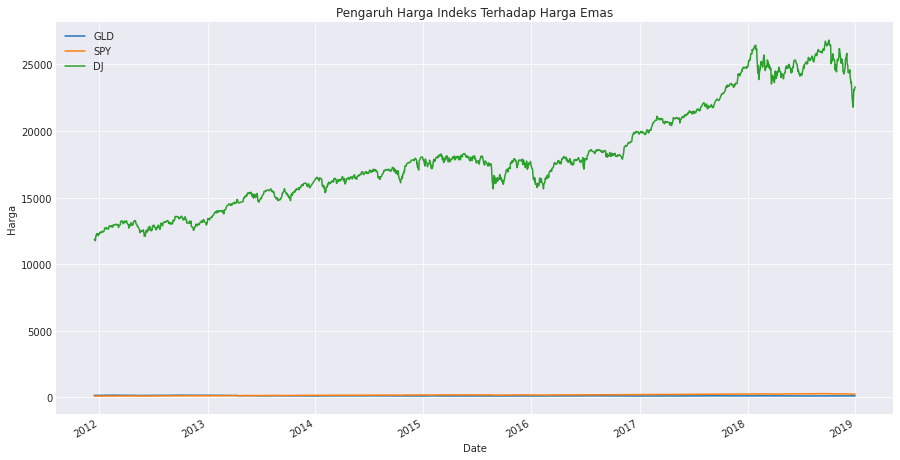

In [ ]:
# Mengambil data harga penutupan yang disesuaikan (Adjusted Close)
GLD_adj_close = df['Adj Close']
SPY_adj_close = df['SP_Ajclose']
DJ_adj_close  = df['DJ_Ajclose']

# Membuat DataFrame baru untuk analisis
df_p = pd.DataFrame({'GLD': GLD_adj_close, 'SPY': SPY_adj_close, 'DJ': DJ_adj_close})

# Membuat plot untuk melihat hubungan antara harga emas dan harga indeks
df_ax = df_p.plot(title='Pengaruh Harga Indeks Terhadap Harga Emas', figsize=(15, 8))

# Menambahkan label dan legenda pada plot
df_ax.set_ylabel('Harga')
df_ax.legend(loc='upper left')

# Menampilkan plot
plt.show()


## **Menghitung Return Harian dari Semua Fitur**
Pada bagian ini, kita akan menghitung return harian dari berbagai fitur yang telah tersedia. Return harian dihitung dengan rumus berikut:

\[
\text{Return harian} = \frac{\text{Harga hari ini}}{\text{Harga hari sebelumnya}} - 1
\]

Setelah menghitung return harian untuk setiap fitur, kita akan memvisualisasikan return harian terakhir (100 data terakhir) untuk analisis lebih lanjut.


In [ ]:
# Fungsi untuk menghitung return harian
def compute_daily_returns(df):
    """Menghitung dan mengembalikan nilai return harian."""
    # Return harian dihitung berdasarkan harga hari ini dibandingkan dengan harga hari sebelumnya
    daily_return = (df / df.shift(1)) - 1
    daily_return[0] = 0  # Nilai pada baris pertama di-set ke 0
    return daily_return

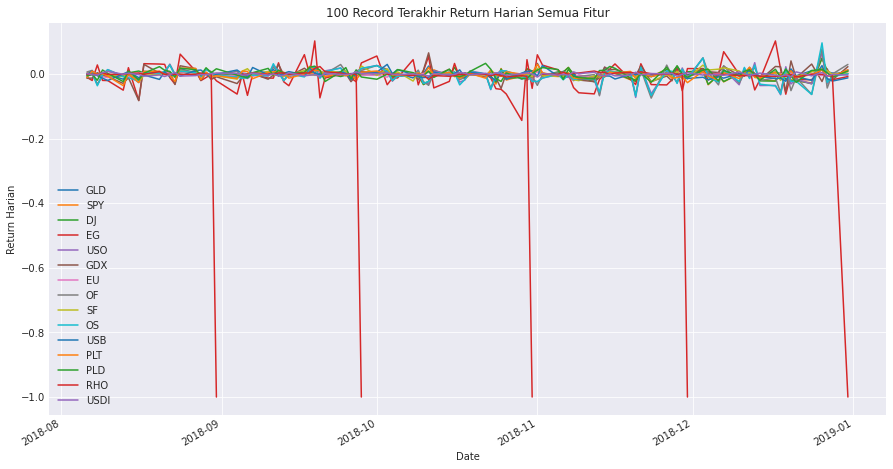

In [ ]:
# Mengambil data harga adjusted close untuk berbagai fitur
GLD_adj_close = df['Adj Close']
SPY_adj_close = df['SP_Ajclose']
DJ_adj_close  = df['DJ_Ajclose']
EG_adj_close =  df['EG_Ajclose']
USO_Adj_close = df['USO_Adj Close']
GDX_Adj_close = df['GDX_Adj Close']
EU_price      = df['EU_Price']
OF_price      = df['OF_Price']
OS_price      = df['OS_Price']
SF_price      = df['SF_Price']
USB_price      = df['USB_Price']
PLT_price      = df['PLT_Price']
PLD_price      = df['PLD_Price']
rho_price      = df['RHO_PRICE']
usdi_price      = df['USDI_Price']

# Menghitung return harian untuk setiap fitur
GLD_daily_return = compute_daily_returns(GLD_adj_close)
SPY_daily_return = compute_daily_returns(SPY_adj_close)
DJ_adj_return    = compute_daily_returns(DJ_adj_close)
EG_adj_return     = compute_daily_returns(EG_adj_close)
USO_Adj_return    = compute_daily_returns(USO_Adj_close)
GDX_Adj_return   = compute_daily_returns(GDX_Adj_close)
EU_return        = compute_daily_returns(EU_price)
OF_price         = compute_daily_returns(OF_price)
OS_price         = compute_daily_returns(OS_price)
SF_price         = compute_daily_returns(SF_price)
USB_price         = compute_daily_returns(USB_price)
PLT_price         = compute_daily_returns(PLT_price)
PLD_price         = compute_daily_returns(PLD_price)
rho_price         = compute_daily_returns(rho_price)
USDI_price         = compute_daily_returns(usdi_price)

# Membuat DataFrame untuk semua return harian
df_d = pd.DataFrame({'GLD': GLD_daily_return, 'SPY': SPY_daily_return, 'DJ': DJ_adj_return, 'EG': EG_adj_return, 'USO': USO_Adj_return,
                     'GDX': GDX_Adj_return, 'EU': EU_return, 'OF': OF_price, 'SF': SF_price, 'OS': OS_price, 'USB': USB_price, 'PLT': PLT_price, 'PLD': PLD_price,
                     'RHO': rho_price, 'USDI': USDI_price})

# Menampilkan plot untuk 100 record terakhir return harian
daily_ax = df_d[-100:].plot(title='100 Record Terakhir Return Harian Semua Fitur', figsize=(15, 8))

# Menambahkan label dan legenda pada plot
daily_ax.set_ylabel('Return Harian')
daily_ax.legend(loc='lower left')

# Menampilkan plot
plt.show()

## **Menghitung Return Harian dari Indeks Saham**
Pada bagian ini, kita akan menghitung return harian dari indeks saham yang relevan, yaitu **Gold ETF (GLD)**, **S&P 500 Index (SPY)**, dan **Dow Jones Index (DJ)**. Return harian dihitung untuk memahami fluktuasi harga harian dari masing-masing indeks saham.

Setelah menghitung return harian, kita akan memvisualisasikan 100 data terakhir dari return harian indeks saham ini untuk analisis lebih lanjut.


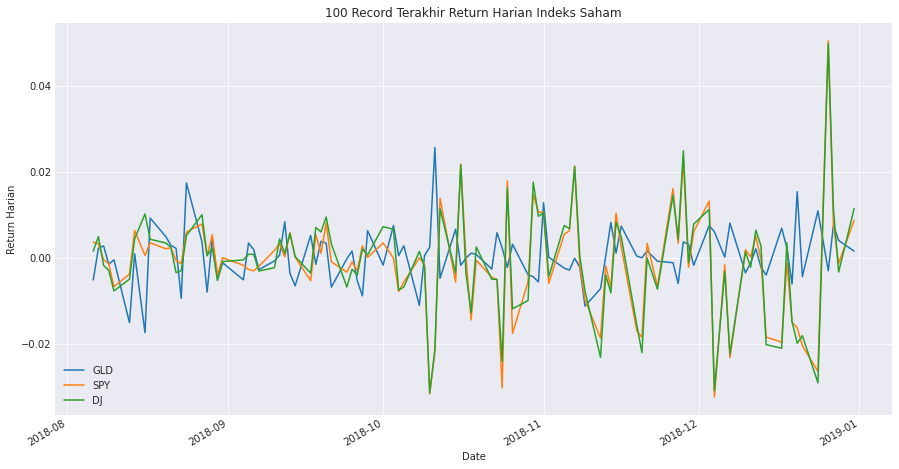

In [ ]:
# Membuat DataFrame untuk return harian indeks saham
df_s = pd.DataFrame({'GLD': GLD_daily_return, 'SPY': SPY_daily_return, 'DJ': DJ_adj_return})

# Menampilkan plot untuk 100 record terakhir return harian indeks saham
daily_ax = df_s[-100:].plot(title='100 Record Terakhir Return Harian Indeks Saham', figsize=(15, 8))

# Menambahkan label dan legenda pada plot
daily_ax.set_ylabel('Return Harian')
daily_ax.legend(loc='lower left')

# Menampilkan plot
plt.show()


## **Scatterplot**
Scatterplot digunakan untuk melihat hubungan antara dua variabel secara visual. Pada bagian ini, kita akan membuat beberapa scatterplot untuk menganalisis hubungan antara harga emas (GLD) dan berbagai fitur yang mungkin mempengaruhi harga emas, seperti indeks saham, harga minyak, dan harga logam mulia lainnya.

Berikut adalah scatterplot yang menunjukkan hubungan antara **Gold ETF (GLD)** dan beberapa fitur ekonomi dan keuangan lainnya.


<AxesSubplot:title={'center':'Hubungan antara PLD dan GLD'}, xlabel='PLD', ylabel='GLD'>

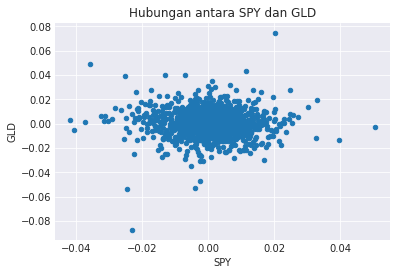

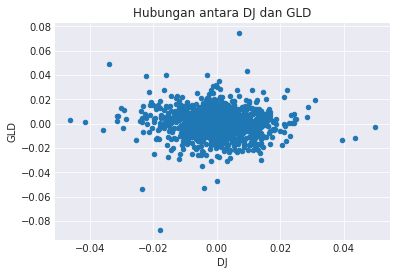

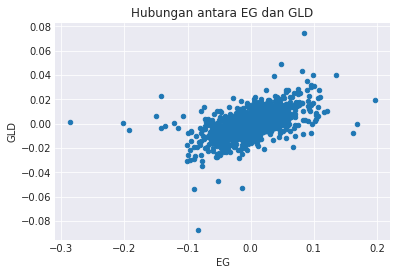

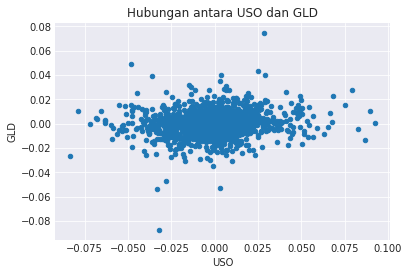

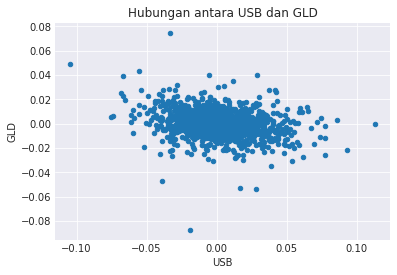

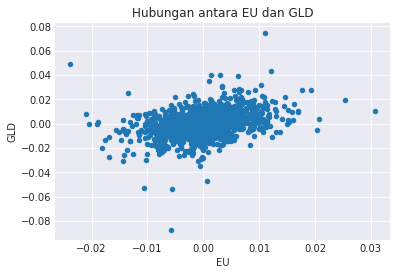

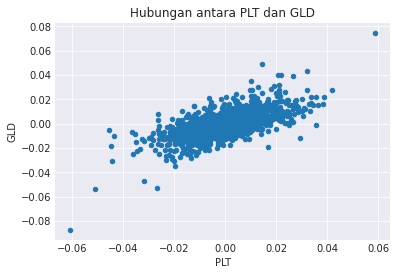

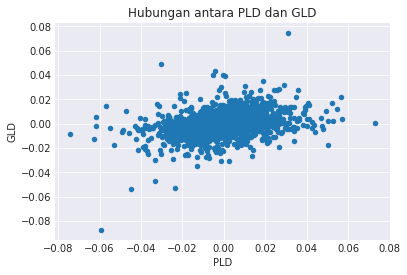

In [ ]:
# Membuat scatterplot untuk melihat hubungan antara GLD dan berbagai fitur lainnya
df_d.plot(kind='scatter', x='SPY', y='GLD', title='Hubungan antara SPY dan GLD')
df_d.plot(kind='scatter', x='DJ', y='GLD', title='Hubungan antara DJ dan GLD')
df_d.plot(kind='scatter', x='EG', y='GLD', title='Hubungan antara EG dan GLD')
df_d.plot(kind='scatter', x='USO', y='GLD', title='Hubungan antara USO dan GLD')
df_d.plot(kind='scatter', x='USB', y='GLD', title='Hubungan antara USB dan GLD')
df_d.plot(kind='scatter', x='EU', y='GLD', title='Hubungan antara EU dan GLD')
df_d.plot(kind='scatter', x='PLT', y='GLD', title='Hubungan antara PLT dan GLD')
df_d.plot(kind='scatter', x='PLD', y='GLD', title='Hubungan antara PLD dan GLD')


## **Statistical Measures (Mean, Standard deviation, Kurtosis)**

**Kurtosis** adalah ukuran statistik yang digunakan untuk menggambarkan distribusi data. Sementara skewness membedakan nilai ekstrim di salah satu sisi distribusi, kurtosis mengukur nilai ekstrim di kedua sisi. Distribusi dengan kurtosis tinggi menunjukkan data ekor yang melebihi ekor distribusi normal (misalnya, lima atau lebih deviasi standar dari rata-rata). Sebaliknya, distribusi dengan kurtosis rendah menunjukkan data ekor yang lebih sedikit ekstrem daripada distribusi normal.

Bagi investor, **kurtosis** yang tinggi pada distribusi return mengindikasikan bahwa investor mungkin akan mengalami return yang sangat ekstrim (baik positif maupun negatif), lebih ekstrem daripada + atau - tiga deviasi standar dari rata-rata yang diprediksi oleh distribusi normal. Fenomena ini dikenal sebagai **kurtosis risk**.

### **Positive Kurtosis**
Distribusi dengan lebih banyak data pada ekor dibandingkan dengan puncak distribusi normal.

### **Negative Kurtosis**
Distribusi dengan data yang lebih merata di kedua ekor dibandingkan dengan puncak.

Mean= -8.65698612128203e-05
Standard Deviation= 0.00961153616700639
Kurtosis= 8.606584924918355


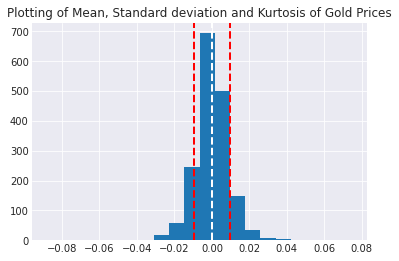

In [ ]:
# Menghitung mean, standard deviation, dan kurtosis dari return harian Gold ETF

mean = df_d['GLD'].mean()  # Rata-rata
std = df_d['GLD'].std()  # Deviasi standar
kurt = df_d['GLD'].kurtosis()  # Kurtosis
print('Mean=', mean)
print('Standard Deviation=', std)
print('Kurtosis=', kurt)

# Plotting Histogram untuk Gold ETF
df_d['GLD'].hist(bins=20)

plt.axvline(mean, color='w', linestyle='dashed', linewidth=2)
plt.axvline(std, color='r', linestyle='dashed', linewidth=2)
plt.axvline(-std, color='r', linestyle='dashed', linewidth=2)
plt.title("Plotting of Mean, Standard deviation and Kurtosis of Gold Prices")
plt.show()

Mean= 0.0005366024364688838
Standard Deviation= 0.008262309911393526
Kurtosis= 3.4557859039745233


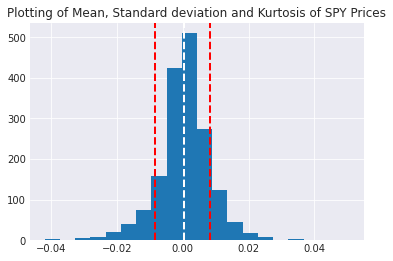

In [ ]:
# Menghitung mean, standard deviation, dan kurtosis dari return harian S&P 500 Index

mean = df_d['SPY'].mean()
std = df_d['SPY'].std()
kurt = df_d['SPY'].kurtosis()
print('Mean=', mean)
print('Standard Deviation=', std)
print('Kurtosis=', kurt)

# Plotting Histogram untuk S&P 500
df_d['SPY'].hist(bins=20)

plt.axvline(mean, color='w', linestyle='dashed', linewidth=2)
plt.axvline(std, color='r', linestyle='dashed', linewidth=2)
plt.axvline(-std, color='r', linestyle='dashed', linewidth=2)
plt.title("Plotting of Mean, Standard deviation and Kurtosis of SPY Prices")
plt.show()

Mean= 0.0004266395218751805
Standard Deviation= 0.00815178011451231
Kurtosis= 3.832719336260695


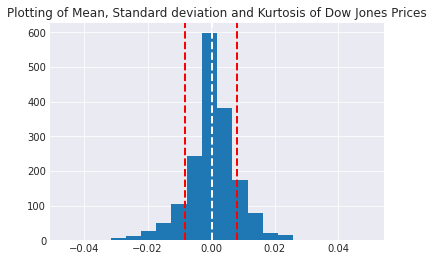

In [ ]:
# Menghitung mean, standard deviation, dan kurtosis dari return harian Dow Jones Index

mean = df_d['DJ'].mean()
std = df_d['DJ'].std()
kurt = df_d['DJ'].kurtosis()
print('Mean=', mean)
print('Standard Deviation=', std)
print('Kurtosis=', kurt)

# Plotting Histogram untuk Dow Jones
df_d['DJ'].hist(bins=20)

plt.axvline(mean, color='w', linestyle='dashed', linewidth=2)
plt.axvline(std, color='r', linestyle='dashed', linewidth=2)
plt.axvline(-std, color='r', linestyle='dashed', linewidth=2)
plt.title("Plotting of Mean, Standard deviation and Kurtosis of Dow Jones Prices")
plt.show()

## Correlation Analysis

### **Plotting Correlation Matrix**

Untuk memvisualisasikan hubungan antara berbagai fitur dalam dataset, kita dapat menggunakan matriks korelasi. Matriks korelasi ini menunjukkan sejauh mana hubungan antar fitur dengan target variabel, yaitu harga emas yang disesuaikan (**Adj Close**).

Kode di bawah ini memvisualisasikan matriks korelasi menggunakan heatmap dan juga menghitung korelasi fitur-fitur lainnya terhadap **Adj Close**.



<AxesSubplot:>

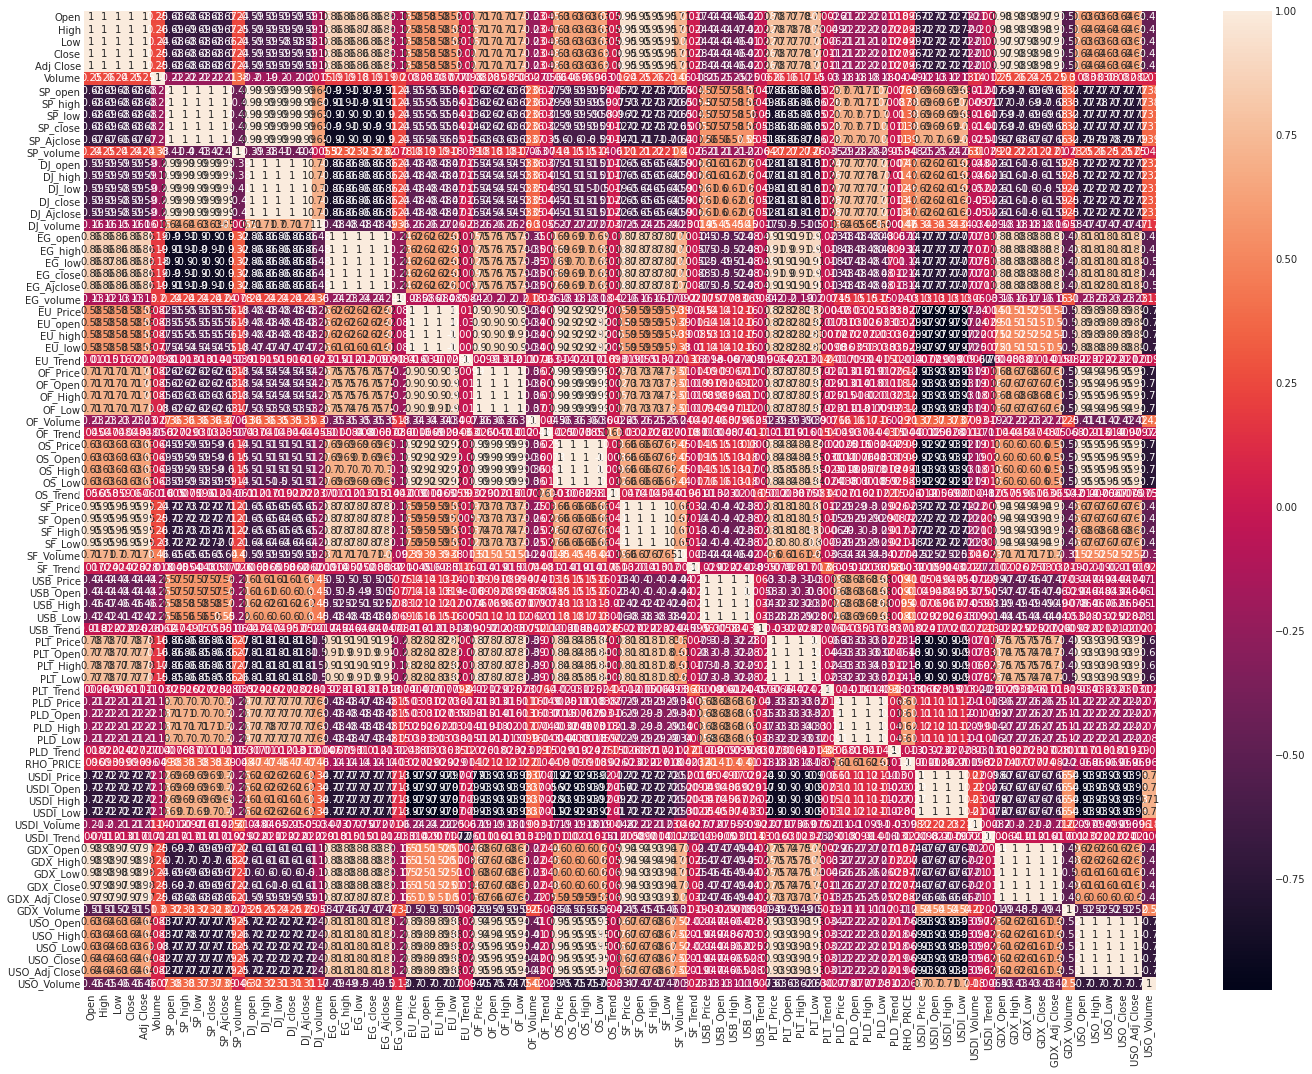

In [ ]:
# Menggambar Correlation Matrix menggunakan heatmap
plt.figure(figsize=(24,18))
sns.heatmap(df.corr(), annot=True)  # Menampilkan korelasi antar fitur dalam dataset

In [ ]:
# Menghitung korelasi fitur-fitur terhadap 'Adj Close'
X = df.drop(['Adj Close'], axis=1)  # Menghapus kolom 'Adj Close' dari fitur
X = X.drop(['Close'], axis=1)  # Menghapus kolom 'Close' dari fitur

<AxesSubplot:title={'center':'Correlation with Adj Close'}>

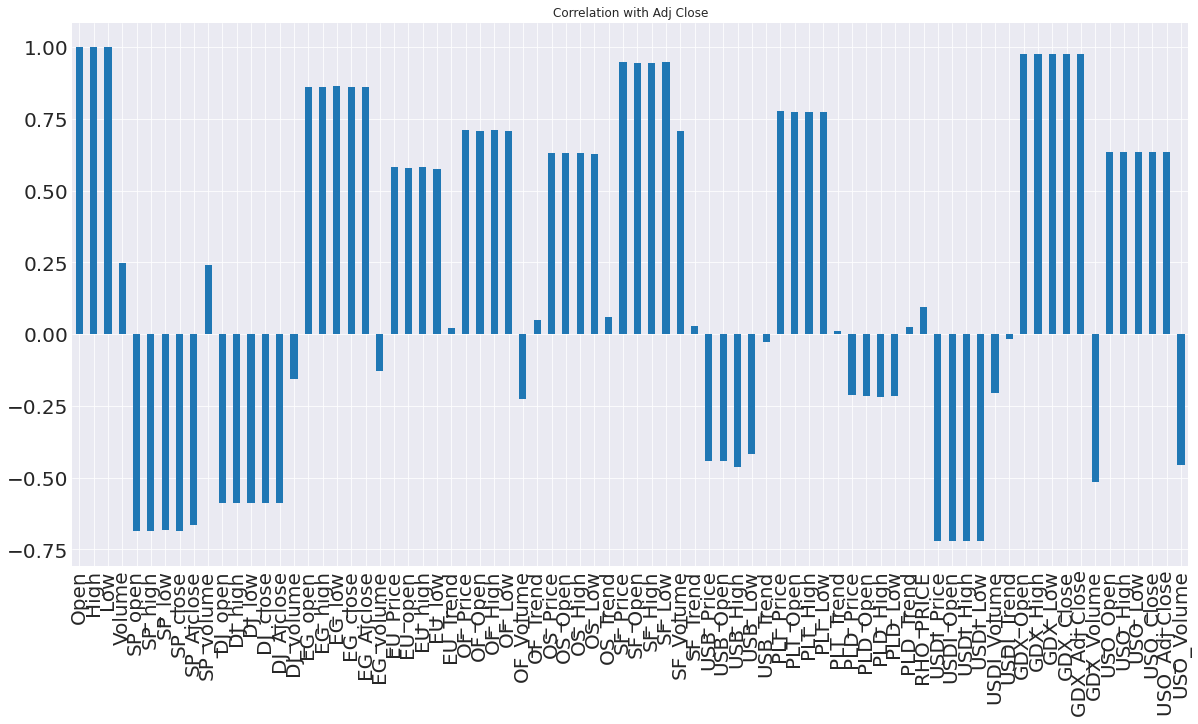

In [ ]:
# Menampilkan korelasi setiap fitur dengan 'Adj Close' dalam bentuk grafik bar
X.corrwith(df['Adj Close']).plot.bar(
    figsize=(20, 10), title="Correlation with Adj Close", fontsize=20,
    rot=90, grid=True)

In [ ]:
# Menyusun koefisien korelasi 'Adj Close' secara menurun
corr_matrix = df.corr()
coef = corr_matrix["Adj Close"].sort_values(ascending=False)

### **Positively Correlated Variables**

Pada analisis korelasi, variabel yang memiliki nilai korelasi positif dengan **Adj Close** menunjukkan hubungan yang searah dengan harga emas. Korelasi positif berarti saat satu variabel meningkat, variabel lainnya juga cenderung meningkat.



In [ ]:
# Menyaring variabel dengan korelasi positif terhadap 'Adj Close'
pos_corr = coef[coef > 0]
pos_corr


Close            1.000000
Adj Close        1.000000
High             0.999535
Low              0.999532
Open             0.998976
GDX_Low          0.975561
GDX_Close        0.975459
GDX_High         0.975255
GDX_Adj Close    0.974980
GDX_Open         0.974824
SF_Low           0.947842
SF_Price         0.947420
SF_Open          0.945557
SF_High          0.945203
EG_low           0.863917
EG_open          0.862900
EG_close         0.862770
EG_high          0.861479
EG_Ajclose       0.859850
PLT_Price        0.775861
PLT_High         0.775481
PLT_Low          0.773993
PLT_Open         0.773760
OF_High          0.711334
OF_Price         0.710693
OF_Open          0.709096
OF_Low           0.708266
SF_Volume        0.706505
USO_Adj Close    0.635675
USO_Close        0.635675
USO_High         0.635311
USO_Open         0.635197
USO_Low          0.634732
OS_High          0.632001
OS_Price         0.630817
OS_Open          0.630046
OS_Low           0.629083
EU_high          0.582969
EU_Price    

### **Negatively Correlated Variables**

Variabel yang memiliki korelasi negatif dengan **Adj Close** menunjukkan hubungan yang berlawanan arah dengan harga emas. Korelasi negatif berarti saat satu variabel meningkat, variabel lainnya cenderung menurun.


In [ ]:
# Menyaring variabel dengan korelasi negatif terhadap 'Adj Close'
neg_corr = coef[coef < 0]
neg_corr


USDI_Trend    -0.016641
USB_Trend     -0.025933
EG_volume     -0.126586
DJ_volume     -0.155526
USDI_Volume   -0.205954
PLD_Price     -0.213179
PLD_Low       -0.214919
PLD_Open      -0.216426
PLD_High      -0.217490
OF_Volume     -0.225436
USB_Low       -0.417352
USB_Open      -0.440822
USB_Price     -0.441347
USO_Volume    -0.456193
USB_High      -0.464116
GDX_Volume    -0.514616
DJ_low        -0.588157
DJ_Ajclose    -0.588411
DJ_close      -0.588411
DJ_high       -0.588778
DJ_open       -0.588800
SP_Ajclose    -0.666071
SP_low        -0.683750
SP_close      -0.684284
SP_open       -0.684618
SP_high       -0.684904
USDI_High     -0.720023
USDI_Open     -0.720140
USDI_Price    -0.721569
USDI_Low      -0.722078
Name: Adj Close, dtype: float64

## **Technical Indicators**

Saya juga akan menggunakan indikator teknikal berikut yang saya rasa dapat membantu sebagai fitur dalam prediksi harga emas:

**1. MACD (Moving Average Convergence Divergence):** MACD adalah salah satu indikator yang paling kuat dan terkenal dalam analisis teknikal. Indikator ini terdiri dari dua exponential moving averages yang membantu mengukur momentum dalam suatu keamanan. MACD adalah selisih antara dua moving averages tersebut yang dipetakan terhadap garis tengah, di mana garis tengah adalah titik di mana kedua moving averages tersebut setara.

**2. RSI (Relative Strength Index):** RSI adalah indikator momentum yang juga terkenal dan banyak digunakan dalam analisis teknikal. Indikator ini biasa digunakan untuk mengidentifikasi kondisi overbought (jenuh beli) dan oversold (jenuh jual) dalam suatu keamanan, dengan rentang antara 0 (oversold) dan 100 (overbought).

**3. Simple Moving Average (SMA):** SMA hanya mengambil jumlah dari seluruh harga penutupan yang terjadi dalam periode waktu tertentu dan membaginya dengan jumlah harga yang digunakan dalam perhitungan. Misalnya, SMA 10 hari mengambil harga penutupan terakhir selama 10 hari dan membaginya dengan 10.

**4. Upper Band:** Band atas pada indikator Bollinger Bands.

**5. Lower Band:** Band bawah pada indikator Bollinger Bands.

**6. DIFF:** Selisih antara dua exponential moving averages pada MACD.

**7. Open-Close:** Selisih antara harga pembukaan dan penutupan.

**8. High-Low:** Selisih antara harga tertinggi dan terendah.



In [ ]:
# Fungsi untuk menghitung MACD (Moving Average Convergence Divergence)
def calculate_MACD(df, nslow=26, nfast=12):
    emaslow = df.ewm(span=nslow, min_periods=nslow, adjust=True, ignore_na=False).mean()
    emafast = df.ewm(span=nfast, min_periods=nfast, adjust=True, ignore_na=False).mean()
    dif = emafast - emaslow
    MACD = dif.ewm(span=9, min_periods=9, adjust=True, ignore_na=False).mean()
    return dif, MACD

# Fungsi untuk menghitung RSI (Relative Strength Index)
def calculate_RSI(df, periods=14):
    # Wilder's RSI
    delta = df.diff()
    up, down = delta.copy(), delta.copy()

    up[up < 0] = 0
    down[down > 0] = 0

    rUp = up.ewm(com=periods, adjust=False).mean()
    rDown = down.ewm(com=periods, adjust=False).mean().abs()

    rsi = 100 - 100 / (1 + rUp / rDown)
    return rsi

# Fungsi untuk menghitung SMA (Simple Moving Average)
def calculate_SMA(df, periods=15):
    SMA = df.rolling(window=periods, min_periods=periods, center=False).mean()
    return SMA

# Fungsi untuk menghitung Bollinger Bands (BB)
def calculate_BB(df, periods=15):
    STD = df.rolling(window=periods, min_periods=periods, center=False).std()
    SMA = calculate_SMA(df)
    upper_band = SMA + (2 * STD)
    lower_band = SMA - (2 * STD)
    return upper_band, lower_band

# Fungsi untuk menghitung Standar Deviasi (Stdev)
def calculate_stdev(df, periods=5):
    STDEV = df.rolling(periods).std()
    return STDEV


## **Plotting Technical Indicators**

Pada bagian ini, kita akan memplot beberapa indikator teknikal untuk menganalisis harga emas (GLD), yang mencakup **Simple Moving Average (SMA)**, **Bollinger Bands (BB)**, **MACD**, **RSI**, dan **Standar Deviasi (STDEV)**.



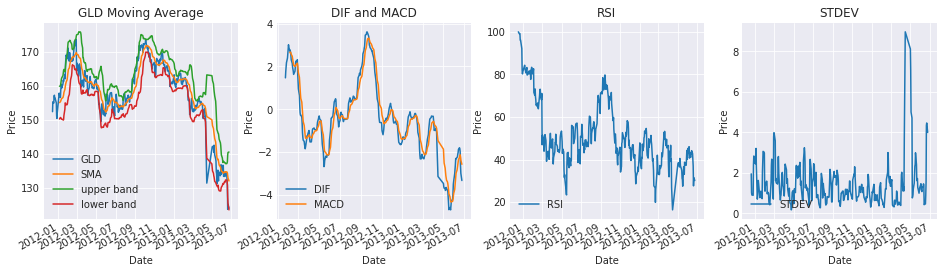

In [ ]:
# Membuat subplots untuk menampilkan indikator teknikal
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16, 4))

# Menghitung Simple Moving Average untuk GLD
SMA_GLD = calculate_SMA(GLD_adj_close)

GLD_adj_close[:365].plot(title='GLD Moving Average', label='GLD', ax=axes[0])
SMA_GLD[:365].plot(label="SMA", ax=axes[0])

# Menghitung Bollinger Bands untuk GLD
upper_band, lower_band = calculate_BB(GLD_adj_close)

upper_band[:365].plot(label='upper band', ax=axes[0])
lower_band[:365].plot(label='lower band', ax=axes[0])

# Menghitung MACD untuk GLD
DIF, MACD = calculate_MACD(GLD_adj_close)

DIF[:365].plot(title='DIF and MACD', label='DIF', ax=axes[1])
MACD[:365].plot(label='MACD', ax=axes[1])

# Menghitung RSI untuk GLD
RSI = calculate_RSI(GLD_adj_close)
RSI[:365].plot(title='RSI', label='RSI', ax=axes[2])

# Menghitung Standar Deviasi (STDEV) untuk GLD
STDEV = calculate_stdev(GLD_adj_close)
STDEV[:365].plot(title='STDEV', label='STDEV', ax=axes[3])

# Menghitung selisih Open-Close dan High-Low
Open_Close = df.Open - df.Close
High_Low = df.High - df.Low

# Menambahkan label pada setiap axis
axes[0].set_ylabel('Price')
axes[1].set_ylabel('Price')
axes[2].set_ylabel('Price')
axes[3].set_ylabel('Price')

# Menambahkan legend pada setiap plot
axes[0].legend(loc='lower left')
axes[1].legend(loc='lower left')
axes[2].legend(loc='lower left')
axes[3].legend(loc='lower left')

# Menampilkan grafik
plt.show()


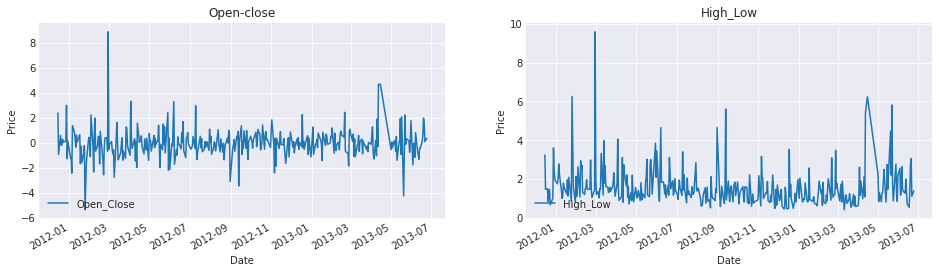

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))

# Menghitung selisih Open-Close
Open_Close = df.Open - df.Close
Open_Close[:365].plot(title='Open-close', label='Open_Close', ax=axes[0])

# Menghitung selisih High-Low
High_Low = df.High - df.Low
High_Low[:365].plot(title='High_Low', label='High_Low', ax=axes[1])

# Menambahkan label pada sumbu Y
axes[0].set_ylabel('Price')
axes[1].set_ylabel('Price')

# Menambahkan legend pada setiap plot
axes[0].legend(loc='lower left')
axes[1].legend(loc='lower left')

# Menampilkan grafik
plt.show()


## Data Preparation

In [ ]:
test = df  # Menggunakan df sebagai data utama
test['SMA'] = SMA_GLD
test['Upper_band'] = upper_band
test['Lower_band'] = lower_band
test['DIF'] = DIF
test['MACD'] = MACD
test['RSI'] = RSI
test['STDEV'] = STDEV
test['Open_Close'] = Open_Close
test['High_Low'] = High_Low

# Menghapus 33 baris pertama karena memiliki nilai null akibat pengenalan indikator teknikal
test = test[33:]

# Kolom target (Adj Close)
target_adj_close = pd.DataFrame(test['Adj Close'])

# Menampilkan beberapa baris pertama dari test
display(test.head())


,Open,High,Low,Close,Adj Close,Volume,SP_open,SP_high,SP_low,SP_close,...,USO_Volume,SMA,Upper_band,Lower_band,DIF,MACD,RSI,STDEV,Open_Close,High_Low
Date,,,,,,,,,,,,,,,,,,,,,
2012-02-06,166.960007,167.679993,166.610001,167.179993,167.179993,8807400,133.979996,134.509995,133.830002,134.449997,...,6126100,165.198666,173.018365,157.378968,2.724443,2.641891,70.144545,1.562107,-0.219986,1.069992
2012-02-07,167.380005,170.089996,167.149994,169.699997,169.699997,11614300,134.169998,135.020004,133.639999,134.789993,...,10237000,165.894667,173.296304,158.493029,2.754381,2.667095,73.152763,1.594111,-2.319992,2.940002
2012-02-08,169.259995,169.960007,167.500000,168.500000,168.500000,10655500,134.860001,135.220001,134.309998,135.190002,...,9045800,166.428000,173.297467,159.558533,2.655845,2.664634,69.576023,1.575718,0.759995,2.460007
2012-02-09,170.009995,170.369995,167.669998,168.020004,168.020004,16085200,135.410004,135.589996,134.559998,135.360001,...,4663500,166.856000,173.217507,160.494493,2.511947,2.631843,68.148015,0.965153,1.989991,2.699997
2012-02-10,166.490005,167.639999,166.330002,167.139999,167.139999,10326800,134.160004,134.470001,133.839996,134.360001,...,6008600,167.250666,172.795817,161.705515,2.303734,2.562404,65.507009,1.059963,-0.649994,1.309997


In [ ]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'SP_open',
       'SP_high', 'SP_low', 'SP_close', 'SP_Ajclose', 'SP_volume', 'DJ_open',
       'DJ_high', 'DJ_low', 'DJ_close', 'DJ_Ajclose', 'DJ_volume', 'EG_open',
       'EG_high', 'EG_low', 'EG_close', 'EG_Ajclose', 'EG_volume', 'EU_Price',
       'EU_open', 'EU_high', 'EU_low', 'EU_Trend', 'OF_Price', 'OF_Open',
       'OF_High', 'OF_Low', 'OF_Volume', 'OF_Trend', 'OS_Price', 'OS_Open',
       'OS_High', 'OS_Low', 'OS_Trend', 'SF_Price', 'SF_Open', 'SF_High',
       'SF_Low', 'SF_Volume', 'SF_Trend', 'USB_Price', 'USB_Open', 'USB_High',
       'USB_Low', 'USB_Trend', 'PLT_Price', 'PLT_Open', 'PLT_High', 'PLT_Low',
       'PLT_Trend', 'PLD_Price', 'PLD_Open', 'PLD_High', 'PLD_Low',
       'PLD_Trend', 'RHO_PRICE', 'USDI_Price', 'USDI_Open', 'USDI_High',
       'USDI_Low', 'USDI_Volume', 'USDI_Trend', 'GDX_Open', 'GDX_High',
       'GDX_Low', 'GDX_Close', 'GDX_Adj Close', 'GDX_Volume', 'USO_Open',
       'USO_High', 'USO

In [ ]:
# Pemilihan kolom fitur
feature_columns = ['Open', 'High', 'Low', 'Volume','SP_open','SP_high','SP_low','SP_Ajclose','SP_volume','DJ_open','DJ_high', 'DJ_low',  'DJ_Ajclose', 'DJ_volume', 'EG_open','EG_high', 'EG_low',
                   'EG_Ajclose', 'EG_volume', 'EU_Price','EU_open', 'EU_high', 'EU_low', 'EU_Trend', 'OF_Price','OF_Open','OF_High', 'OF_Low', 'OF_Volume', 'OF_Trend', 'OS_Price', 'OS_Open','OS_High', 'OS_Low', 'OS_Trend', 'SF_Price', 'SF_Open', 'SF_High',
                   'SF_Low', 'SF_Volume', 'SF_Trend', 'USB_Price', 'USB_Open', 'USB_High','USB_Low', 'USB_Trend', 'PLT_Price', 'PLT_Open', 'PLT_High', 'PLT_Low',
                    'PLT_Trend', 'PLD_Price', 'PLD_Open', 'PLD_High', 'PLD_Low','PLD_Trend', 'RHO_PRICE', 'USDI_Price', 'USDI_Open', 'USDI_High',
                     'USDI_Low', 'USDI_Volume', 'USDI_Trend','GDX_Open', 'GDX_High',
       'GDX_Low', 'GDX_Close', 'GDX_Adj Close', 'GDX_Volume', 'USO_Open',
       'USO_High', 'USO_Low', 'USO_Close', 'USO_Adj Close', 'USO_Volume','SMA', 'Upper_band', 'Lower_band', 'DIF', 'MACD','RSI','STDEV','Open_Close', 'High_Low']



## Normalisasi Data

Pada langkah ini, saya akan melakukan skala fitur/normalisasi terhadap variabel fitur menggunakan fungsi MinMaxScaler dari sklearn untuk mengubah nilai fitur menjadi rentang antara 0 dan 1.

Langkah-langkah ini akan memastikan bahwa seluruh fitur berada dalam skala yang seragam, yang sangat penting untuk model pembelajaran mesin yang sensitif terhadap skala data, seperti jaringan saraf atau regresi linier.

Fitur-fitur yang sudah dinormalisasi akan digunakan untuk melatih model, sementara target (harga penutupan yang disesuaikan) akan digeser untuk memprediksi nilai di hari berikutnya.

Setelah proses normalisasi, data akan dibagi menjadi data pelatihan dan data validasi. Data validasi akan menggunakan 90 baris terakhir untuk menguji model, sementara data pelatihan akan menggunakan sisanya.

Setelah proses ini, kita akan memastikan bahwa dimensi data fitur dan target telah disesuaikan untuk pelatihan dan validasi.


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Inisialisasi MinMaxScaler
scaler = MinMaxScaler()

# Normalisasi kolom fitur
feature_minmax_transform_data = scaler.fit_transform(test[feature_columns])

# Membuat DataFrame dengan fitur yang sudah dinormalisasi
feature_minmax_transform = pd.DataFrame(columns=feature_columns, data=feature_minmax_transform_data, index=test.index)




In [ ]:
# Menampilkan beberapa baris pertama dari fitur yang sudah dinormalisasi
display(feature_minmax_transform.head())

# Menampilkan bentuk dari fitur dan target
print('Shape of features: ', feature_minmax_transform.shape)
print('Shape of target: ', target_adj_close.shape)

# Menggeser target array karena kita ingin memprediksi nilai pada hari n+1
target_adj_close = target_adj_close.shift(-1)

# Membuat set validasi (90 hari terakhir untuk validasi)
validation_y = target_adj_close[-90:-1]
target_adj_close = target_adj_close[:-90]

# Membuat set fitur validasi (90 hari terakhir untuk validasi)
validation_X = feature_minmax_transform[-90:-1]

# Menghapus 90 baris terakhir dari set fitur
feature_minmax_transform = feature_minmax_transform[:-90]

# Menampilkan baris terakhir dari fitur validasi dan target
display(validation_X.tail())
display(validation_y.tail())

# Menampilkan bentuk data fitur dan target setelah proses pembagian
print("\n -----After process------ \n")
print('Shape of features: ', feature_minmax_transform.shape)
print('Shape of target: ', target_adj_close.shape)
display(target_adj_close.tail())

,Open,High,Low,Volume,SP_open,SP_high,SP_low,SP_Ajclose,SP_volume,DJ_open,...,USO_Volume,SMA,Upper_band,Lower_band,DIF,MACD,RSI,STDEV,Open_Close,High_Low
Date,,,,,,,,,,,,,,,,,,,,,
2012-02-06,0.913669,0.912561,0.913193,0.079151,0.037098,0.034927,0.040627,0.028113,0.166542,0.051563,...,0.046608,0.906189,0.961240,0.821988,0.893394,0.911893,0.807275,0.167603,0.415010,0.091684
2012-02-07,0.919480,0.945539,0.920622,0.109560,0.038247,0.038015,0.039473,0.029765,0.224602,0.050453,...,0.084243,0.916193,0.965092,0.837893,0.896986,0.915193,0.852413,0.171198,0.280308,0.291045
2012-02-08,0.945490,0.943760,0.925437,0.099173,0.042423,0.039225,0.043542,0.031707,0.232599,0.051907,...,0.073338,0.923859,0.965108,0.853105,0.885164,0.914871,0.798744,0.169132,0.477870,0.239873
2012-02-09,0.955866,0.949370,0.927775,0.157998,0.045752,0.041465,0.045060,0.032533,0.251876,0.053171,...,0.033218,0.930011,0.964000,0.866467,0.867900,0.910578,0.777317,0.100533,0.556766,0.265458
2012-02-10,0.907167,0.912014,0.909341,0.095612,0.038187,0.034685,0.040687,0.027676,0.292146,0.053519,...,0.045532,0.935684,0.958155,0.883757,0.842920,0.901486,0.737688,0.111185,0.387428,0.117271


Shape of features:  (1685, 84)
Shape of target:  (1685, 1)


,Open,High,Low,Volume,SP_open,SP_high,SP_low,SP_Ajclose,SP_volume,DJ_open,...,USO_Volume,SMA,Upper_band,Lower_band,DIF,MACD,RSI,STDEV,Open_Close,High_Low
Date,,,,,,,,,,,,,,,,,,,,,
2018-12-21,0.252767,0.249863,0.252304,0.131396,0.719499,0.732264,0.685249,0.721173,0.474541,0.731087,...,0.346662,0.221370,0.217009,0.228105,0.658641,0.648503,0.687759,0.071990,0.459268,0.050107
2018-12-24,0.258024,0.262042,0.266061,0.089215,0.672900,0.678571,0.650574,0.685607,0.249183,0.693452,...,0.188254,0.225663,0.221905,0.231591,0.673309,0.655308,0.771343,0.103731,0.400256,0.038380
2018-12-26,0.272551,0.273810,0.266061,0.138587,0.654321,0.710896,0.647477,0.751818,0.397651,0.662258,...,0.365682,0.228778,0.225424,0.234153,0.680140,0.662243,0.728779,0.105509,0.490699,0.130064
2018-12-27,0.271859,0.272441,0.273903,0.112378,0.694263,0.723668,0.679055,0.762387,0.330444,0.714615,...,0.325400,0.232083,0.233069,0.232846,0.692906,0.670576,0.782400,0.071859,0.429121,0.058636
2018-12-28,0.275042,0.274904,0.281882,0.058103,0.736686,0.742494,0.724540,0.760598,0.261258,0.754292,...,0.199288,0.235840,0.241125,0.232010,0.706157,0.680136,0.808642,0.092629,0.412444,0.015992


,Adj Close
Date,
2018-12-21,120.019997
2018-12-24,119.660004
2018-12-26,120.570000
2018-12-27,121.059998
2018-12-28,121.250000



 -----After process------ 

Shape of features:  (1595, 84)
Shape of target:  (1595, 1)


,Adj Close
Date,
2018-08-13,113.070000
2018-08-14,111.099998
2018-08-16,112.129997
2018-08-17,112.690002
2018-08-20,113.019997


## Pembagian Data Pelatihan dan Pengujian

Pada langkah ini, kita akan melakukan pembagian data pelatihan dan pengujian dengan menggunakan teknik `TimeSeriesSplit` dari sklearn. Teknik ini sangat berguna untuk data deret waktu (time series) karena mempertahankan urutan waktu yang benar saat membagi data. Ini memastikan bahwa model pelatihan hanya menggunakan data sebelum titik waktu tertentu, yang lebih sesuai dengan masalah prediksi.

Dengan menggunakan `TimeSeriesSplit`, kita dapat membagi data menjadi beberapa bagian (folds) dan melakukan validasi silang pada data deret waktu. Pada setiap iterasi, sebagian data digunakan untuk pelatihan, dan sebagian lainnya digunakan untuk pengujian.

Dalam hal ini, kami akan menggunakan 10 pembagian (folds) untuk data pelatihan dan pengujian


In [ ]:
from sklearn.model_selection import TimeSeriesSplit

# Inisialisasi TimeSeriesSplit dengan 10 pembagian
ts_split = TimeSeriesSplit(n_splits=10)

# Pembagian data untuk pelatihan dan pengujian
for train_index, test_index in ts_split.split(feature_minmax_transform):
    X_train, X_test = feature_minmax_transform[:len(train_index)], feature_minmax_transform[len(train_index): (len(train_index)+len(test_index))]
    y_train, y_test = target_adj_close[:len(train_index)].values.ravel(), target_adj_close[len(train_index): (len(train_index)+len(test_index))].values.ravel()

# Menampilkan bentuk data pelatihan dan pengujian
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (1450, 84)
Shape of X_test: (145, 84)
Shape of y_train: (1450,)
Shape of y_test: (145,)


## Validasi Hasil Model

Pada langkah ini, kita akan memvalidasi hasil dari model yang telah dilatih dengan menggunakan data validasi (`validation_X` dan `validation_y`). Validasi ini dilakukan dengan menghitung dua metrik penting, yaitu **RMSE (Root Mean Squared Error)** dan **R² (Coefficient of Determination)**, yang digunakan untuk mengukur seberapa baik model dalam memprediksi harga.

### RMSE (Root Mean Squared Error)
RMSE adalah metrik yang digunakan untuk mengukur perbedaan antara nilai yang diprediksi dan nilai aktual. Semakin rendah nilai RMSE, semakin baik model dalam memprediksi.

### R² (Coefficient of Determination)
R² mengukur seberapa baik model dalam menjelaskan variansi dalam data. Nilai R² berkisar antara 0 hingga 1, dengan nilai yang lebih tinggi menunjukkan model yang lebih baik.

Setelah menghitung metrik-metrik tersebut, kita juga akan memvisualisasikan hasil prediksi model dan nilai aktual pada grafik yang sama untuk melihat seberapa dekat hasil prediksi dengan data sebenarnya.


In [ ]:
def validate_result(model, model_name):
    # Melakukan prediksi dengan model
    predicted = model.predict(validation_X)

    # Menghitung RMSE
    RMSE_score = np.sqrt(mean_squared_error(validation_y, predicted))
    print('RMSE: ', RMSE_score)

    # Menghitung R² score
    R2_score = r2_score(validation_y, predicted)
    print('R2 score: ', R2_score)

    # Plotting prediksi vs aktual
    plt.plot(validation_y.index, predicted, 'r', label='Predict')
    plt.plot(validation_y.index, validation_y, 'b', label='Actual')
    plt.ylabel('Price')
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.title(model_name + ' Predict vs Actual')
    plt.legend(loc='upper right')
    plt.show()


## Pembangunan Model

### 1. Model Benchmark:
       Saya akan menggunakan Decision Tree Regressor dengan parameter default sebagai model benchmark untuk proyek ini. Model ini akan digunakan untuk membandingkan hasil dengan model lain yang lebih kompleks, agar dapat mengetahui seberapa baik model yang lebih canggih jika dibandingkan dengan model dasar.

Decision Tree Regressor adalah salah satu algoritma pembelajaran mesin yang dapat digunakan untuk melakukan regresi, dan akan membantu kita dalam memprediksi harga berdasarkan data historis yang ada.

Langkah selanjutnya adalah membangun model Decision Tree dan melakukan validasi hasil prediksi dengan menghitung metrik RMSE dan R² serta memvisualisasikan hasilnya.


RMSE:  1.2166871700124942
R2 score:  0.6590361406118342


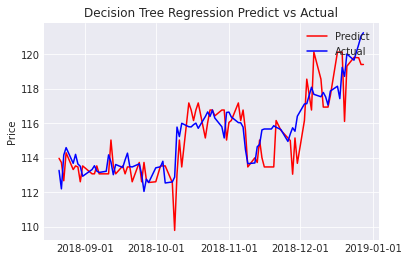

In [ ]:
# Membuat dan melatih model Decision Tree
dt = DecisionTreeRegressor(random_state=0)

# Melatih model dengan data pelatihan
benchmark_dt = dt.fit(X_train, y_train)

# Validasi hasil prediksi menggunakan model Decision Tree
validate_result(benchmark_dt, 'Decision Tree Regression')


## Model Solusi

### Support Vector Regressor (SVR)

Pada bagian ini, kita akan menggunakan **Support Vector Regressor (SVR)** dengan kernel linear sebagai model solusi untuk memprediksi harga. SVR adalah salah satu metode regresi yang menggunakan konsep Support Vector Machines (SVM), yang sering digunakan untuk masalah regresi dengan data yang tidak terlalu besar dan memiliki margin yang jelas.

Dengan memilih kernel linear, kita berharap model dapat menangani data secara efektif dan memberikan prediksi yang cukup baik.

Setelah melatih model, kita akan melakukan validasi untuk melihat seberapa baik model ini dapat memprediksi harga berdasarkan data yang ada.



RMSE:  0.8136915781869215
R2 score:  0.8474998982807777


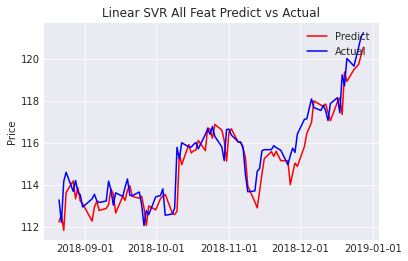

In [ ]:
# Menyimpan semua model solusi
solution_models = {}

# SVR dengan Kernel Linear
svr_lin = SVR(kernel='linear')

# Melatih model SVR dengan kernel linear
linear_svr_clf_feat = svr_lin.fit(X_train, y_train)

# Validasi hasil prediksi menggunakan Linear SVR
validate_result(linear_svr_clf_feat, 'Linear SVR All Feat')


### Tuning Hyperparameter
Pada langkah ini, kita akan melakukan tuning terhadap dua parameter dari **Support Vector Regressor (SVR)**, yaitu parameter **C** dan **epsilon** untuk melihat apakah ada peningkatan performa pada model.

- **C** adalah parameter yang mengatur tingkat kesalahan yang diizinkan oleh model. Semakin besar nilai C, model akan mencoba untuk lebih mengurangi kesalahan, tetapi bisa menyebabkan overfitting.
- **Epsilon** adalah parameter yang menentukan margin kesalahan yang dapat diterima dalam model. Nilai epsilon yang lebih kecil mengindikasikan bahwa model lebih sensitif terhadap kesalahan.

Dengan melakukan **Grid Search** pada kedua parameter ini, kita berharap dapat menemukan kombinasi yang menghasilkan model yang lebih baik.



RMSE:  0.7417766706111801
R2 score:  0.8732649232935971


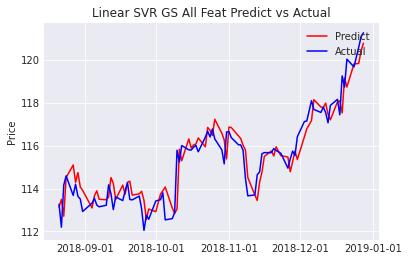

In [ ]:
# Menentukan parameter yang akan dicari pada GridSearch
linear_svr_parameters = {
    'C': [0.5, 1.0, 10.0, 50.0],
    'epsilon': [0, 0.1, 0.5, 0.7, 0.9],
}

# Melakukan GridSearchCV untuk mencari kombinasi terbaik dari C dan epsilon
lsvr_grid_search_feat = GridSearchCV(estimator=linear_svr_clf_feat,
                           param_grid=linear_svr_parameters,
                           cv=ts_split,
)

# Melatih model dengan GridSearchCV
lsvr_grid_search_feat.fit(X_train, y_train)

# Validasi hasil model dengan GridSearch
validate_result(lsvr_grid_search_feat, 'Linear SVR GS All Feat')


Seperti yang kita lihat, dengan menggunakan **GridSearch** pada **Support Vector Regressor (SVR)**, kita mendapatkan peningkatan signifikan pada nilai **R2** dan penurunan **RMSE**. Hal ini menunjukkan bahwa tuning parameter **C** dan **epsilon** memberikan perbaikan pada model. Oleh karena itu, kita akan menyimpan model ini sebagai **solusi pertama** yang optimal.

In [ ]:
# Menyimpan model SVR yang sudah di-tuning dengan GridSearch sebagai solusi pertama
solution_models['SVR All Feat'] = lsvr_grid_search_feat

## Solution Model: Random Forest

Pada langkah ini, saya akan menggunakan model Random Forest untuk membangun model prediksi dengan semua fitur yang ada. Model ini akan digunakan untuk membandingkan kinerjanya dengan model SVR yang telah di-tuning sebelumnya.



RMSE:  0.8078828885891266
R2 score:  0.8496694277726002


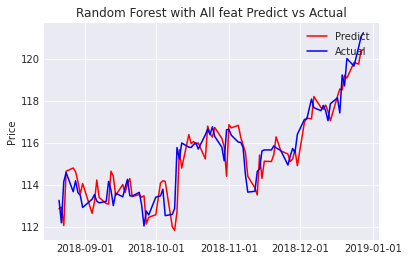

In [ ]:
# Membuat model Random Forest dengan 50 estimator
rf_cl = RandomForestRegressor(n_estimators=50, random_state=0)
random_forest_clf_feat = rf_cl.fit(X_train, y_train)

# Melakukan validasi terhadap model Random Forest
validate_result(random_forest_clf_feat, 'Random Forest with All feat')


## Hyperparameter Tuning
Pada langkah ini, saya akan melakukan tuning terhadap tiga parameter model Random Forest, yaitu `n_estimators`, `max_features`, dan `max_depth`. Tujuannya adalah untuk meningkatkan kinerja model dengan memilih kombinasi parameter terbaik.



In [ ]:
# Mendefinisikan parameter yang akan di-tune untuk Random Forest
random_forest_parameters = {
    'n_estimators': [10, 15, 20, 50, 100],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [2, 3, 5, 7, 10],
}

# Menggunakan GridSearchCV untuk melakukan pencarian parameter terbaik dengan cross-validation
grid_search_RF_feat = GridSearchCV(estimator=random_forest_clf_feat,
                           param_grid=random_forest_parameters,
                           cv=ts_split,
)

# Menjalankan pencarian parameter terbaik
grid_search_RF_feat.fit(X_train, y_train)


GridSearchCV(cv=TimeSeriesSplit(max_train_size=None, n_splits=10),
             estimator=RandomForestRegressor(n_estimators=50, random_state=0),
             param_grid={'max_depth': [2, 3, 5, 7, 10],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'n_estimators': [10, 15, 20, 50, 100]})

{'max_depth': 7, 'max_features': 'auto', 'n_estimators': 20}
RMSE:  0.8221622242794646
R2 score:  0.8443082757939838


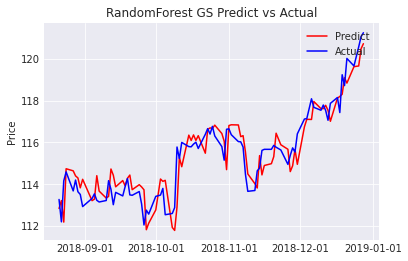

In [ ]:
# Menampilkan parameter terbaik yang ditemukan oleh GridSearchCV
print(grid_search_RF_feat.best_params_)

# Validasi model dengan parameter terbaik
validate_result(grid_search_RF_feat,'RandomForest GS')


Seperti yang kita lihat, Random Forest dengan parameter default memberikan hasil yang lebih baik dibandingkan dengan model Random Forest yang sudah dituning. Oleh karena itu, kita akan memasukkan Random Forest dengan parameter default sebagai model solusi kedua.


In [ ]:
# Menyimpan model Random Forest dengan parameter default ke dalam dictionary solusi
solution_models['Random_Forest with Feat'] = random_forest_clf_feat


## Model Solusi : Lasso dan Ridge

Pada langkah ini, saya akan menggunakan model Lasso dan Ridge sebagai model solusi tambahan. Kedua model ini adalah regresi linier yang dilengkapi dengan regularisasi yang membantu mencegah overfitting dengan menambahkan penalti pada fungsi kerugian.

### LassoCV:
Lasso regresi menggunakan regularisasi L1, yang mendorong sparsitas pada koefisien. Ini berguna ketika kita percaya bahwa hanya beberapa fitur yang penting untuk memprediksi variabel target.

### RidgeCV:
Ridge regresi menggunakan regularisasi L2, yang menambahkan penalti pada fungsi kerugian berdasarkan kuadrat dari koefisien. Ini berguna ketika kita memiliki banyak fitur kecil atau fitur yang saling berkorelasi.



RMSE:  0.7117047240324116
R2 score:  0.8833324203076942


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_coordinate_descent.py:531: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 47.274631125088035, tolerance: 47.12975638074313
  positive)


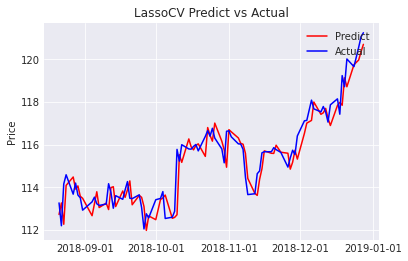

RMSE:  0.7186272523103391
R2 score:  0.8810518047764179


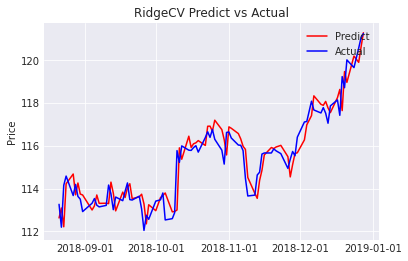

In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.linear_model import RidgeCV

# Lasso Regression dengan Cross-validation
lasso_clf = LassoCV(n_alphas=1000, max_iter=3000, random_state=0)
lasso_clf_feat = lasso_clf.fit(X_train, y_train)
validate_result(lasso_clf_feat, 'LassoCV')
solution_models['LassoCV All feat'] = lasso_clf_feat

# Ridge Regression dengan Cross-validation
ridge_clf = RidgeCV(gcv_mode='auto')
ridge_clf_feat = ridge_clf.fit(X_train, y_train)
validate_result(ridge_clf_feat, 'RidgeCV')
solution_models['RidgeCV All Feat'] = ridge_clf_feat


## Model Solusi : Bayesian Ridge

Pada langkah ini, saya akan menggunakan model **Bayesian Ridge**. Model ini merupakan regresi linier dengan regularisasi yang menggunakan pendekatan Bayesian. Tujuan utamanya adalah untuk menaksir distribusi parameter model dan tidak hanya memberikan satu set koefisien terbaik.



RMSE:  0.7195639601669016
R2 score:  0.8807415122717521


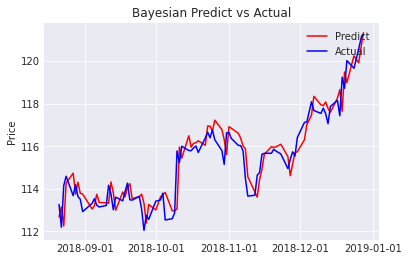

In [ ]:
from sklearn import linear_model

# Bayesian Ridge Regression
bay = linear_model.BayesianRidge()
bay_feat = bay.fit(X_train, y_train)
validate_result(bay_feat, 'Bayesian')
solution_models['Bay All Feat'] = bay_feat


## Model Solusi : Gradient Boosting Regressor

Pada langkah ini, saya akan menggunakan model **Gradient Boosting Regressor**. Gradient Boosting adalah teknik ensemble yang membangun model prediksi dalam bentuk pohon keputusan yang kuat dan berurutan untuk meminimalkan kesalahan model secara bertahap. Model ini bekerja dengan cara menggabungkan banyak model pohon keputusan lemah untuk menghasilkan prediksi yang lebih akurat.



RMSE:  0.8094931831292806
R2 score:  0.8490695443986875


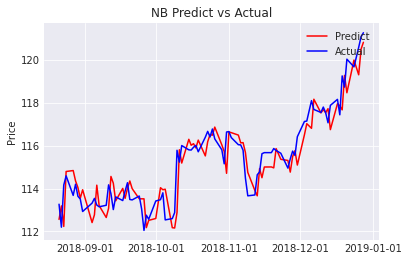

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Gradient Boosting Regressor
regr = GradientBoostingRegressor(n_estimators=70, learning_rate=0.1, max_depth=4, random_state=0, loss='ls')
GB_feat = regr.fit(X_train, y_train)
validate_result(GB_feat, 'NB')
solution_models['GB All Feat'] = GB_feat


## Model Solusi : Stochastic Gradient Descent (SGD)

Pada langkah ini, saya akan menggunakan **Stochastic Gradient Descent (SGD)** sebagai model regresi. SGD adalah teknik optimisasi yang menggunakan iterasi acak pada subset data untuk memperbarui parameter model. SGD cocok untuk masalah dengan dataset besar dan dapat digunakan dengan berbagai jenis fungsi kerugian.



RMSE:  0.9141489449988743
R2 score:  0.8075205291328325


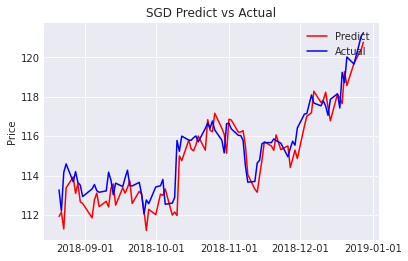

In [ ]:
from sklearn.linear_model import SGDRegressor

# Stochastic Gradient Descent
sgd = SGDRegressor(max_iter=1000, tol=1e-3, loss='squared_epsilon_insensitive', penalty='l1', alpha=0.1)
sgd_feat = sgd.fit(X_train, y_train)
validate_result(sgd_feat, 'SGD')
solution_models['SGD All Feat'] = sgd_feat

## Review Model
Pada langkah ini, kita akan melakukan review terhadap **benchmark model** dan semua **model solusi** yang telah dibangun sebelumnya. Penilaian dilakukan berdasarkan dua metrik evaluasi utama, yaitu **RMSE (Root Mean Squared Error)** dan **R2 Score**.

Kita akan membandingkan performa model-model yang telah dilatih dengan menggunakan data validasi dan melihat seberapa baik model-model tersebut dalam memprediksi harga dengan menghitung nilai RMSE serta memvisualisasikan hasil prediksi model terhadap data aktual.


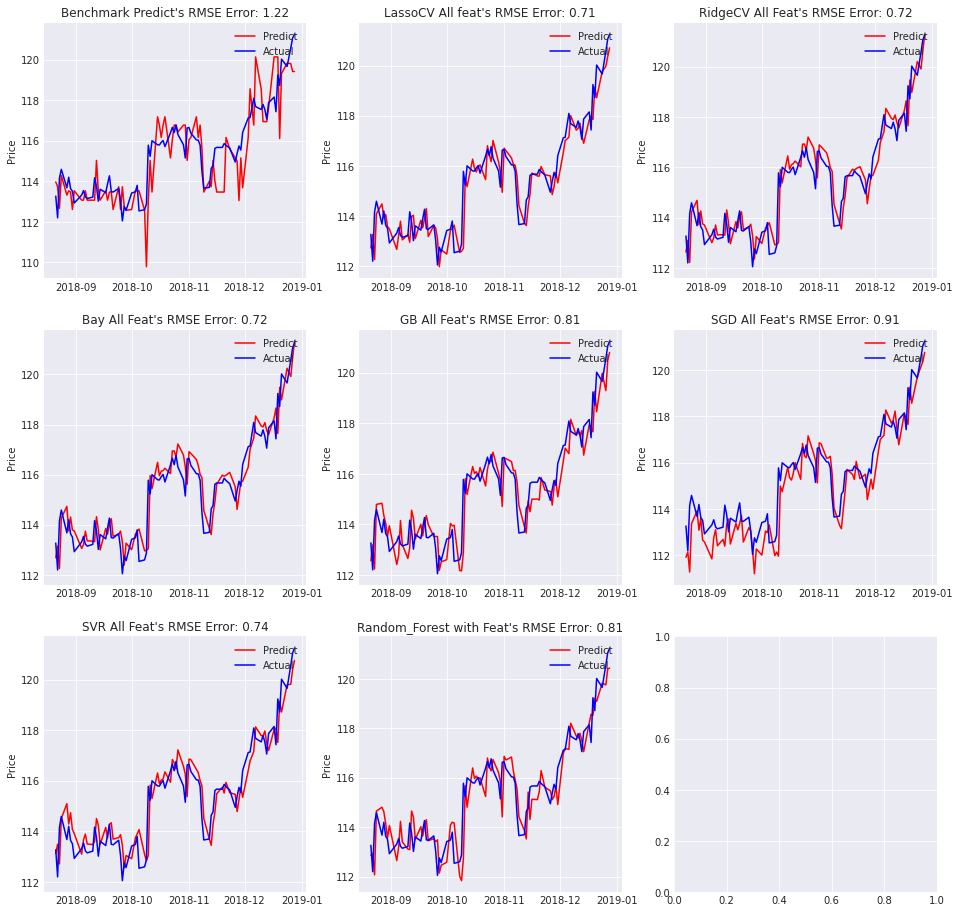

In [ ]:
RMSE_scores = {}
def model_review(models):
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 16))

    #plot benchmark model
    benchmark_predicted = benchmark_dt.predict(validation_X)
    benchmark_RSME_score = np.sqrt(mean_squared_error(validation_y, benchmark_predicted))
    RMSE_scores['Benchmark'] = benchmark_RSME_score

    axes[0,0].plot(validation_y.index, benchmark_predicted,'r', label='Predict')
    axes[0,0].plot(validation_y.index, validation_y,'b', label='Actual')
    axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    axes[0,0].xaxis.set_major_locator(mdates.MonthLocator())
    axes[0,0].set_ylabel('Price')
    axes[0,0].set_title("Benchmark Predict's RMSE Error: " +"{0:.2f}".format(benchmark_RSME_score))
    axes[0,0].legend(loc='upper right')

    #plot block
    ax_x = 0
    ax_y = 1
    #plot solution model
    for name, model in models.items():
        predicted = model.predict(validation_X)
        RSME_score = np.sqrt(mean_squared_error(validation_y, predicted))


        axes[ax_x][ax_y].plot(validation_y.index, predicted,'r', label='Predict')
        axes[ax_x][ax_y].plot(validation_y.index, validation_y,'b', label='Actual')
        axes[ax_x][ax_y].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        axes[ax_x][ax_y].xaxis.set_major_locator(mdates.MonthLocator())
        axes[ax_x][ax_y].set_ylabel('Price')
        axes[ax_x][ax_y].set_title(name + "'s RMSE Error: " +"{0:.2f}".format(RSME_score))
        axes[ax_x][ax_y].legend(loc='upper right')
        RMSE_scores[name] = RSME_score
        if ax_x <=2:
            if ax_y < 2:
                ax_y += 1
            else:
                ax_x += 1
                ax_y = 0
    plt.show()

model_review(solution_models)

### Perbandingan RMSE Antara Benchmark dan Semua Model Solusi

Pada langkah ini, kita akan membandingkan nilai RMSE antara model **Benchmark** dan semua **model solusi** yang telah dibangun. Dengan membandingkan nilai RMSE, kita dapat menilai seberapa baik masing-masing model dalam memprediksi harga. Model dengan RMSE yang lebih rendah menunjukkan performa yang lebih baik dalam hal akurasi prediksi.

Di bawah ini, kita akan menampilkan grafik batang yang menunjukkan perbandingan RMSE antara semua model yang telah dievaluasi.


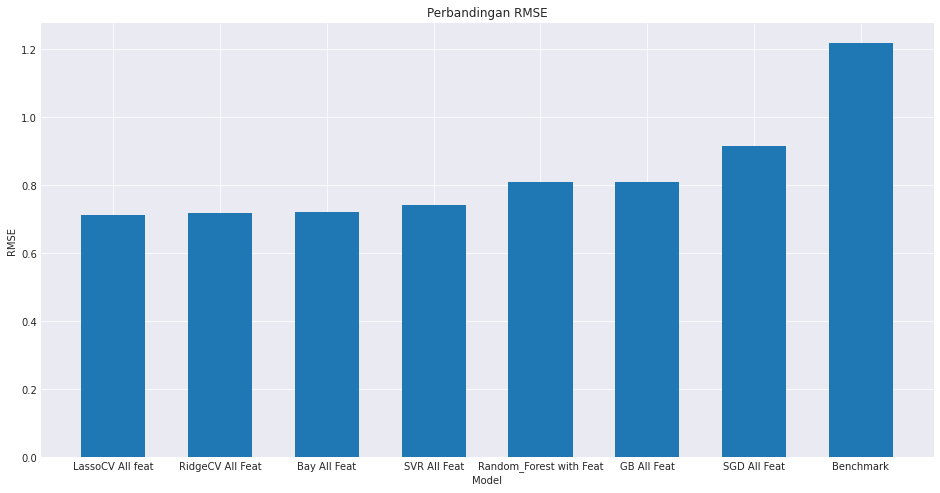

In [ ]:
model_names = []
model_values = []

# Mengumpulkan nama model dan nilai RMSE
for name, value in RMSE_scores.items():
    model_names.append(name)
    model_values.append(value)

model_values = np.array(model_values)
model_names = np.array(model_names)

# Mengurutkan nilai RMSE
indices = np.argsort(model_values)
columns = model_names[indices[:8]]
values = model_values[indices][:8]

# Membuat grafik batang untuk perbandingan RMSE
fig = plt.figure(figsize = (16,8))
plt.bar(np.arange(8), values, width = 0.6, align="center")
plt.xticks(np.arange(8), columns)
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.title('Perbandingan RMSE')
plt.show()


## Pemilihan Fitur

Pada langkah ini, kita akan memilih fitur yang mendukung proses pembuatan model menggunakan **SelectFromModel** dari sklearn. Kami akan menggunakan **Lasso Regressor** karena model ini memiliki nilai RMSE terendah di antara model lainnya. Dengan menggunakan teknik seleksi fitur ini, kita dapat memilih fitur-fitur yang paling relevan untuk prediksi harga.

Fitur-fitur yang dipilih akan digunakan dalam model yang dibangun untuk meningkatkan kinerja dan akurasi.



In [ ]:
from sklearn.feature_selection import SelectFromModel

# Memilih fitur dengan menggunakan Lasso Regressor
sfm = SelectFromModel(lasso_clf_feat)
sfm.fit(feature_minmax_transform, target_adj_close.values.ravel())

# Menampilkan hasil seleksi fitur
display(feature_minmax_transform.head())

# Mendapatkan fitur yang dipilih
sup = sfm.get_support()
zipped = zip(feature_minmax_transform, sup)
print(*zipped)


,Open,High,Low,Volume,SP_open,SP_high,SP_low,SP_Ajclose,SP_volume,DJ_open,...,USO_Volume,SMA,Upper_band,Lower_band,DIF,MACD,RSI,STDEV,Open_Close,High_Low
Date,,,,,,,,,,,,,,,,,,,,,
2012-02-06,0.913669,0.912561,0.913193,0.079151,0.037098,0.034927,0.040627,0.028113,0.166542,0.051563,...,0.046608,0.906189,0.961240,0.821988,0.893394,0.911893,0.807275,0.167603,0.415010,0.091684
2012-02-07,0.919480,0.945539,0.920622,0.109560,0.038247,0.038015,0.039473,0.029765,0.224602,0.050453,...,0.084243,0.916193,0.965092,0.837893,0.896986,0.915193,0.852413,0.171198,0.280308,0.291045
2012-02-08,0.945490,0.943760,0.925437,0.099173,0.042423,0.039225,0.043542,0.031707,0.232599,0.051907,...,0.073338,0.923859,0.965108,0.853105,0.885164,0.914871,0.798744,0.169132,0.477870,0.239873
2012-02-09,0.955866,0.949370,0.927775,0.157998,0.045752,0.041465,0.045060,0.032533,0.251876,0.053171,...,0.033218,0.930011,0.964000,0.866467,0.867900,0.910578,0.777317,0.100533,0.556766,0.265458
2012-02-10,0.907167,0.912014,0.909341,0.095612,0.038187,0.034685,0.040687,0.027676,0.292146,0.053519,...,0.045532,0.935684,0.958155,0.883757,0.842920,0.901486,0.737688,0.111185,0.387428,0.117271


('Open', True) ('High', True) ('Low', True) ('Volume', False) ('SP_open', False) ('SP_high', False) ('SP_low', False) ('SP_Ajclose', False) ('SP_volume', False) ('DJ_open', False) ('DJ_high', False) ('DJ_low', False) ('DJ_Ajclose', False) ('DJ_volume', False) ('EG_open', False) ('EG_high', False) ('EG_low', False) ('EG_Ajclose', False) ('EG_volume', False) ('EU_Price', False) ('EU_open', False) ('EU_high', False) ('EU_low', False) ('EU_Trend', False) ('OF_Price', False) ('OF_Open', False) ('OF_High', False) ('OF_Low', False) ('OF_Volume', False) ('OF_Trend', True) ('OS_Price', False) ('OS_Open', False) ('OS_High', False) ('OS_Low', False) ('OS_Trend', True) ('SF_Price', False) ('SF_Open', False) ('SF_High', False) ('SF_Low', False) ('SF_Volume', True) ('SF_Trend', True) ('USB_Price', False) ('USB_Open', False) ('USB_High', True) ('USB_Low', False) ('USB_Trend', True) ('PLT_Price', False) ('PLT_Open', False) ('PLT_High', False) ('PLT_Low', False) ('PLT_Trend', True) ('PLD_Price', False)

In [ ]:

# Memilih fitur yang mendukung proses pembuatan model
feature_selected = feature_minmax_transform[['Open','High','Low','OF_Trend','USB_Trend','PLT_Trend','USDI_Price','GDX_Close','SMA','Upper_band','RSI','Open_Close']]
feature_selected_validation_X = validation_X[['Open','High','Low','OF_Trend','USB_Trend','PLT_Trend','USDI_Price','GDX_Close','SMA','Upper_band','RSI','Open_Close']]

# Menampilkan fitur terpilih untuk proses pelatihan dan validasi
display(feature_selected.head())
display(feature_selected_validation_X.head())


,Open,High,Low,OF_Trend,USB_Trend,PLT_Trend,USDI_Price,GDX_Close,SMA,Upper_band,RSI,Open_Close
Date,,,,,,,,,,,,
2012-02-06,0.913669,0.912561,0.913193,1.0,0.0,0.0,0.035457,0.974365,0.906189,0.961240,0.807275,0.415010
2012-02-07,0.919480,0.945539,0.920622,1.0,1.0,1.0,0.015007,0.967677,0.916193,0.965092,0.852413,0.280308
2012-02-08,0.945490,0.943760,0.925437,1.0,1.0,1.0,0.017368,0.960098,0.923859,0.965108,0.798744,0.477870
2012-02-09,0.955866,0.949370,0.927775,1.0,1.0,0.0,0.014087,0.953633,0.930011,0.964000,0.777317,0.556766
2012-02-10,0.907167,0.912014,0.909341,0.0,0.0,1.0,0.037058,0.936692,0.935684,0.958155,0.737688,0.387428


,Open,High,Low,OF_Trend,USB_Trend,PLT_Trend,USDI_Price,GDX_Close,SMA,Upper_band,RSI,Open_Close
Date,,,,,,,,,,,,
2018-08-21,0.163946,0.165709,0.167974,1.0,1.0,0.0,0.674324,0.143781,0.169137,0.179197,0.312663,0.413085
2018-08-22,0.172524,0.171045,0.176640,1.0,0.0,0.0,0.670362,0.146901,0.166531,0.173311,0.340181,0.436818
2018-08-23,0.162701,0.162698,0.162746,0.0,1.0,0.0,0.691652,0.133526,0.163714,0.170454,0.271060,0.459910
2018-08-24,0.170587,0.183771,0.178566,1.0,0.0,1.0,0.670842,0.144449,0.163369,0.169642,0.456216,0.370750
2018-08-27,0.182623,0.188697,0.191085,1.0,1.0,1.0,0.655675,0.151806,0.163053,0.168648,0.490053,0.398974


## Train Test Split

Pada langkah ini, kita akan melakukan pembagian data menjadi set pelatihan (training set) dan set pengujian (test set). Pembagian dilakukan menggunakan **TimeSeriesSplit** untuk memastikan bahwa data yang digunakan untuk pelatihan dan pengujian memiliki urutan waktu yang benar. Data pelatihan akan digunakan untuk melatih model, sedangkan data pengujian akan digunakan untuk mengevaluasi performa model.



In [ ]:
# Membagi data menjadi set pelatihan dan pengujian dengan TimeSeriesSplit
for train_index, test_index in ts_split.split(feature_selected):
    X_train, X_test = feature_selected[:len(train_index)], feature_selected[len(train_index): (len(train_index)+len(test_index))]
    y_train, y_test = target_adj_close[:len(train_index)].values.ravel(), target_adj_close[len(train_index): (len(train_index)+len(test_index))].values.ravel()


## Validasi Model dengan Fitur Terpilih untuk Benchmark & Model Solusi

Pada langkah ini, kita akan melakukan validasi terhadap model benchmark dan solusi menggunakan fitur yang telah dipilih sebelumnya. Model akan dievaluasi menggunakan metrik RMSE dan R2 score untuk mengetahui performa model dengan fitur yang terpilih.



In [ ]:
def feature_selected_validate_result(model, model_name):
    predicted = model.predict(feature_selected_validation_X)

    RSME_score = np.sqrt(mean_squared_error(validation_y, predicted))
    R2_score = r2_score(validation_y, predicted)

    print(model_name + '\n')
    print('RMSE: ', RSME_score)
    print('R2 score: ', R2_score)
    print('----------------------')


print('---------Benchmark-------------')
# Benchmark Model - Decision Tree
dt = DecisionTreeRegressor(random_state=0)
benchmark_dt_fs = dt.fit(X_train, y_train)
feature_selected_validate_result(benchmark_dt_fs, 'Decision Tree')

feature_selected_solution_models = {}

print('--------Solution Models--------------')
# Random Forest
random_forest_clf_fs = RandomForestRegressor(random_state=0,
                                             max_depth=3,
                                             max_features='auto',
                                             n_estimators=10
)
random_forest_parameters = {
    'n_estimators':[10, 50, 100],
    'max_features':['auto','sqrt','log2'],
    'max_depth':[3, 5, 7],
}
grid_search_RF_fs = GridSearchCV(estimator=random_forest_clf_fs,
                           param_grid=random_forest_parameters,
                           cv=ts_split,
)
grid_search_RF_fs.fit(X_train, y_train)
feature_selected_validate_result(grid_search_RF_fs, 'Feature selected RandomForest GS')
feature_selected_solution_models['FS_RandomForest'] = grid_search_RF_fs

# Linear SVR
linear_svr_fs = SVR(C=50.0, epsilon=0, kernel='linear')
linear_svr_clf_fs = linear_svr_fs.fit(X_train, y_train)
feature_selected_validate_result(linear_svr_clf_fs, 'Feature selected LSVR')
feature_selected_solution_models['FS_LSVR'] = linear_svr_clf_fs

# Lasso
lasso_fs = LassoCV(n_alphas=1000, max_iter=3000, random_state=0)
lasso_clf_fs = lasso_fs.fit(X_train, y_train)
feature_selected_validate_result(lasso_clf_fs, 'Feature selected LassoCV')
feature_selected_solution_models['FS_Lasso'] = lasso_clf_fs

# Ridge
ridge_fs = RidgeCV(gcv_mode='auto')
ridge_clf_fs = ridge_fs.fit(X_train, y_train)
feature_selected_validate_result(ridge_clf_fs, 'Feature selected RidgeCV')
feature_selected_solution_models['FS_RidgeCV'] = ridge_clf_fs

# Bayesian Ridge
bay = linear_model.BayesianRidge()
bay_feat_fs = bay.fit(X_train, y_train)
feature_selected_validate_result(bay_feat_fs, 'Feature selected BayRidge')
feature_selected_solution_models['Bay_Ridge'] = bay_feat_fs

# Gradient Boosting
regr = GradientBoostingRegressor(n_estimators=70, learning_rate=0.1, max_depth=4, random_state=0, loss='ls')
GB_fs = regr.fit(X_train, y_train)
feature_selected_validate_result(GB_fs, 'Feature selected GB')
feature_selected_solution_models['GB_FS'] = GB_fs

# SGD
sgd = SGDRegressor(max_iter=1000, tol=1e-3, loss='squared_epsilon_insensitive', penalty='l1', alpha=0.1)
sgd_fs = sgd.fit(X_train, y_train)
feature_selected_validate_result(sgd_fs, 'Feature selected SGD')
feature_selected_solution_models['sgd_fs'] = sgd_fs


---------Benchmark-------------
Decision Tree

RMSE:  1.3140710969641578
R2 score:  0.6022701215418467
----------------------
--------Solution Models--------------
Feature selected RandomForest GS

RMSE:  0.8052237275992113
R2 score:  0.850657430616824
----------------------
Feature selected LSVR

RMSE:  0.7160621902397207
R2 score:  0.8818994346855501
----------------------
Feature selected LassoCV

RMSE:  0.7092538002994215
R2 score:  0.8841345815790794
----------------------
Feature selected RidgeCV

RMSE:  0.7179254848438182
R2 score:  0.8812840064235162
----------------------
Feature selected BayRidge

RMSE:  0.7125419009126744
R2 score:  0.8830577871840586
----------------------
Feature selected GB

RMSE:  0.8223529442134774
R2 score:  0.8442360346752706
----------------------
Feature selected SGD

RMSE:  0.768841887515227
R2 score:  0.8638478311689348
----------------------


## Review Model

Pada langkah ini, kita akan melakukan review terhadap model benchmark dan model solusi yang telah dipilih menggunakan fitur yang terpilih. Review dilakukan dengan membandingkan hasil prediksi terhadap data aktual menggunakan metrik RMSE dan R2 score. Grafik hasil prediksi untuk setiap model akan ditampilkan.



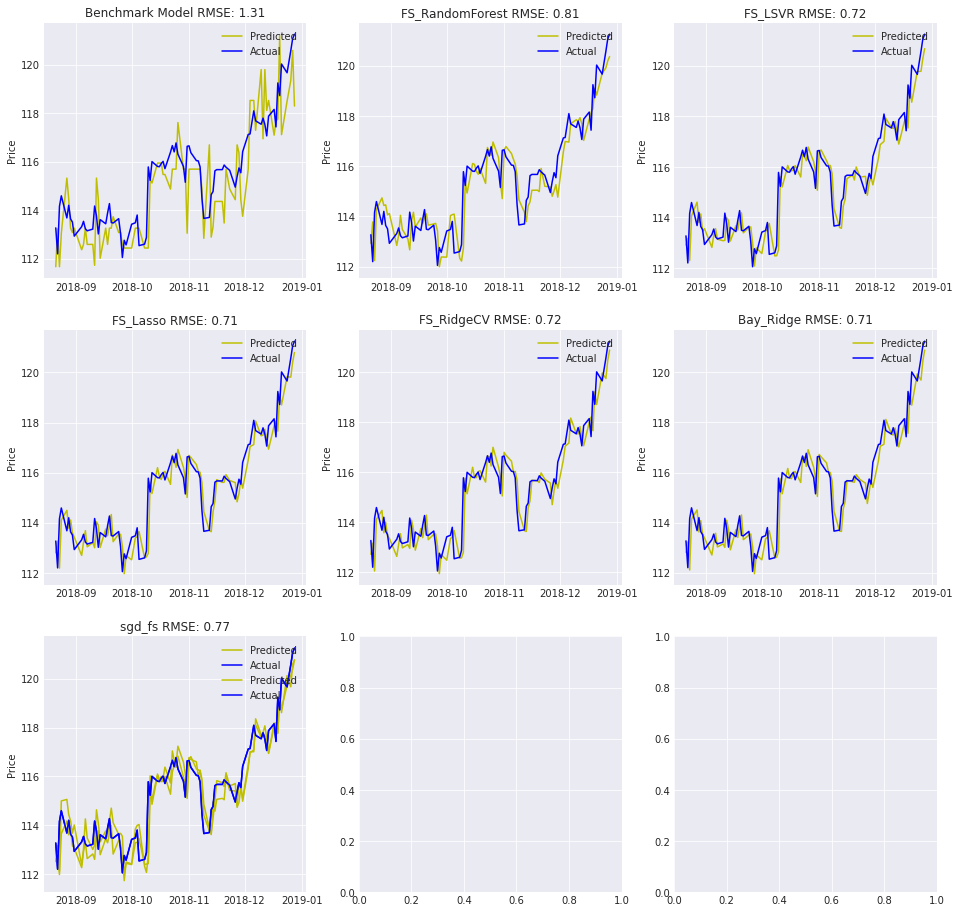

In [ ]:
FS_RMSE_scores = {}

def review_feature_selected_models(models):
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 16))

    # Plot the benchmark model's predictions
    benchmark_predictions = benchmark_dt_fs.predict(feature_selected_validation_X)
    benchmark_rmse = np.sqrt(mean_squared_error(validation_y, benchmark_predictions))
    FS_RMSE_scores['Benchmark'] = benchmark_rmse

    axes[0,0].plot(validation_y.index, benchmark_predictions, 'y', label='Predicted')
    axes[0,0].plot(validation_y.index, validation_y, 'b', label='Actual')
    axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    axes[0,0].xaxis.set_major_locator(mdates.MonthLocator())
    axes[0,0].set_ylabel('Price')
    axes[0,0].set_title(f"Benchmark Model RMSE: {benchmark_rmse:.2f}")
    axes[0,0].legend(loc='upper right')

    # Iterate over solution models
    ax_row, ax_col = 0, 1
    for model_name, model in models.items():
        model_predictions = model.predict(feature_selected_validation_X)
        model_rmse = np.sqrt(mean_squared_error(validation_y, model_predictions))

        # Plot predictions for each model
        axes[ax_row][ax_col].plot(validation_y.index, model_predictions, 'y', label='Predicted')
        axes[ax_row][ax_col].plot(validation_y.index, validation_y, 'b', label='Actual')
        axes[ax_row][ax_col].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        axes[ax_row][ax_col].xaxis.set_major_locator(mdates.MonthLocator())
        axes[ax_row][ax_col].set_ylabel('Price')
        axes[ax_row][ax_col].set_title(f"{model_name} RMSE: {model_rmse:.2f}")
        axes[ax_row][ax_col].legend(loc='upper right')
        FS_RMSE_scores[model_name] = model_rmse

        # Move to the next subplot
        if ax_row < 2:
            if ax_col < 2:
                ax_col += 1
            else:
                ax_row += 1
                ax_col = 0
    plt.show()

# Call the function to review all models
review_feature_selected_models(feature_selected_solution_models)


### Perbandingan RMSE antara Model dengan Fitur Asli dan Fitur yang Telah Dipilih


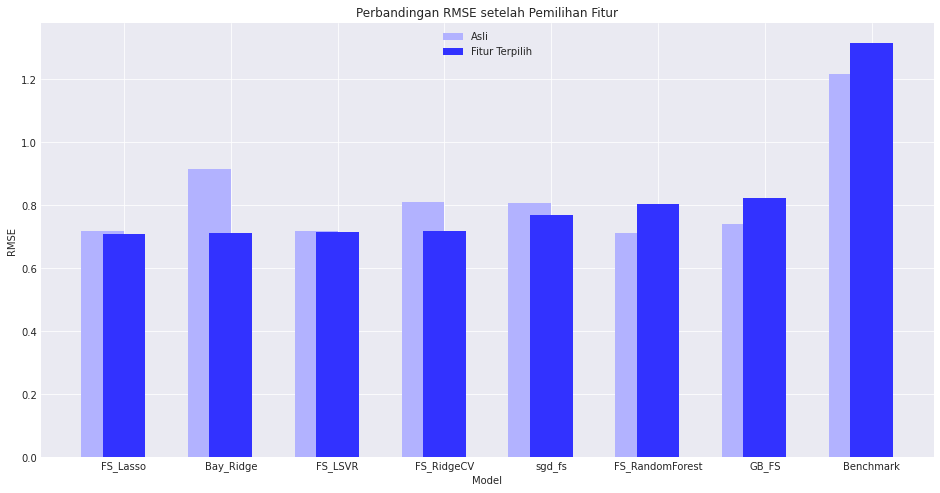

In [ ]:
# Menyiapkan daftar nama model dan nilai RMSE dari model dengan fitur yang terpilih
fs_model_names = []
fs_model_values = []

# Mengumpulkan nama model dan nilai RMSE
for name, value in FS_RMSE_scores.items():
    fs_model_names.append(name)
    fs_model_values.append(value)

# Mengubah list menjadi array numpy untuk memudahkan pemrosesan
fs_model_values = np.array(fs_model_values)
fs_model_names = np.array(fs_model_names)

# Mengurutkan model berdasarkan nilai RMSE untuk menampilkan model terbaik terlebih dahulu
fs_indices = np.argsort(fs_model_values)
fs_columns = fs_model_names[fs_indices[:8]]
fs_values = fs_model_values[fs_indices][:8]
origin_values = model_values[fs_indices][:8]  # Nilai RMSE model asli

# Membuat grafik untuk perbandingan RMSE antara model dengan fitur asli dan fitur yang telah dipilih
fig = plt.figure(figsize=(16, 8))

# Menampilkan grafik untuk RMSE model dengan fitur asli (warna biru muda)
plt.bar(np.arange(8) - 0.2, origin_values, width=0.4, align="center", color='#b2b2ff', label="Asli")

# Menampilkan grafik untuk RMSE model dengan fitur terpilih (warna biru tua)
plt.bar(np.arange(8), fs_values, width=0.4, align="center", color='#3232ff', label="Fitur Terpilih")

# Menambahkan label sumbu X dengan nama model yang terpilih
plt.xticks(np.arange(8), fs_columns)

# Menambahkan label dan judul grafik
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.title('Perbandingan RMSE setelah Pemilihan Fitur')

# Menambahkan legenda di bagian atas grafik
plt.legend(loc='upper center')

# Menampilkan grafik
plt.show()


**Seperti yang dapat kita lihat dari grafik di atas, 3 model yang menggunakan fitur terpilih menunjukkan perbaikan dalam pengurangan error RMSE, dan Feature Selected Linear SVR adalah yang terbaik dengan RMSE 0.716 pada model dengan fitur terpilih, dibandingkan dengan 0.741 pada model dengan semua fitur. Selain itu, Lasso CV dan Bayesian Ridge menunjukkan sedikit perbaikan dibandingkan dengan model fitur asli, sementara Ridge CV tidak menunjukkan perbaikan apa pun dari model fitur asli. Namun, ada empat model yang kinerjanya menurun setelah pemilihan fitur, di mana model benchmark memiliki error RMSE tertinggi dan model SGD mengalami penurunan paling besar dibandingkan dengan model lainnya.**


# Ensemble Solution

Sekarang kita akan menggabungkan tiga model dengan performa terbaik, yaitu Lasso, Bayesian Ridge, dan Ridge untuk model dengan semua fitur. Sedangkan untuk model dengan fitur terpilih, kita akan menggabungkan Lasso, Bayesian Ridge, dan Linear SVR. Kemudian, kita akan membandingkan performa model ensemble dengan semua fitur dan model ensemble dengan fitur terpilih.



In [ ]:
# Memilih tiga model dengan performa terbaik untuk digabungkan
ensemble_solution_models = [lasso_clf_feat, bay_feat, ridge_clf_feat]

class EnsembleModel:
    models = []

    def __init__(self, models):
        self.models = models

    def fit(self, X, y):
        # Melatih setiap model dalam ensemble
        for model in self.models:
            model.fit(X, y)

    def predict(self, X):
        predictions = 0
        # Menghitung prediksi rata-rata dari setiap model dalam ensemble
        for model in self.models:
            predictions += model.predict(X)

        predictions /= len(self.models)  # Rata-rata prediksi

        return predictions


Ensemble Solution Model with Original features
RMSE:  0.7007271848703037
R2 score:  0.8869036929493133


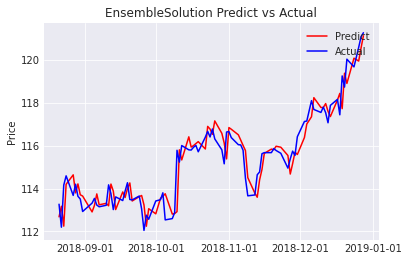

In [ ]:
# Menampilkan hasil dari Ensemble Solution dengan fitur asli
print("Ensemble Solution Model with Original features")
ensemble_model = EnsembleModel(ensemble_solution_models)  # Membuat objek dari kelas EnsembleModel
validate_result(ensemble_model, 'EnsembleSolution')  # Memvalidasi hasil ensemble model


**Ensemble Solution dengan semua fitur menunjukkan hasil terbaik (dengan RMSE 0.70 dan skor R2 sebesar 0.886) dibandingkan dengan model solusi lainnya.**


In [ ]:
# Memilih tiga model dengan performa terbaik untuk digabungkan berdasarkan fitur yang terpilih
ensemble_solution_model_fs = [lasso_clf_fs, bay_feat_fs, linear_svr_clf_fs]

# Membangun model ensemble dengan fitur terpilih
EnsembleModel_fs = EnsembleModel(ensemble_solution_model_fs)

# Melakukan validasi dan evaluasi pada model ensemble dengan fitur terpilih
feature_selected_validate_result(EnsembleModel_fs, 'EnsembleSolution with FS')


EnsembleSolution with FS

RMSE:  0.7106997685521943
R2 score:  0.8836616662485971
----------------------


**Ensemble solution dengan pemilihan fitur memberikan solusi yang lebih baik (RMSE 0.711 dan R2 score 0.884), namun Lasso memiliki kinerja terbaik (RMSE 0.71 dan R2 score 0.884).**


## Melatih Model Beberapa Kali
Dengan menggunakan fungsi train_reg_multipletimes, fungsi ini akan melatih model beberapa kali (saya memilih sebanyak 7 kali) dan menggunakan parameter yang berbeda pada setiap kali dengan TimeSeriesSplit. Setiap kali pelatihan dilakukan, fungsi ini akan menghitung rata-rata nilai R2 dan RMSE. Saya akan menerapkan fungsi ini pada model Benchmark serta pada model solusi terbaik yang menggunakan semua fitur, seperti Linear SVR, Lasso, Ridge, dan Bayesian Ridge, dan membandingkan hasilnya.

In [ ]:
def train_reg_multipletimes(model, times):
    total_rmse = 0
    total_r2 = 0
    for i in range(times):
        reg = model
        for train_index, test_index in TimeSeriesSplit(n_splits=i+2).split(feature_minmax_transform):
            X_train, X_test = feature_minmax_transform[:len(train_index)], feature_minmax_transform[len(train_index): (len(train_index)+len(test_index))]
            y_train, y_test = target_adj_close[:len(train_index)].values.ravel(), target_adj_close[len(train_index): (len(train_index)+len(test_index))].values.ravel()
            reg.fit(X_train, y_train)
        predicted = reg.predict(validation_X)
        rmse, r2 = print_result(validation_y, predicted, [0, len(validation_y)])
        total_rmse += rmse
        total_r2 += r2
    return total_rmse / times, total_r2 / times

def print_result(actual, predict, index):
    RMSE_score = np.sqrt(mean_squared_error(actual, predict))
    print('Dari {} ke {}'.format(index[0], index[-1]))
    print('RMSE: ', RMSE_score)
    R2_score = r2_score(actual, predict)
    print('R2 score: ', R2_score)
    print('---------------------')
    return RMSE_score, R2_score



In [ ]:
# Benchmark
print('Benchmark')
t_multiple_benchmark_RMSE, t_multiple_benchmark_R2 = train_reg_multipletimes(benchmark_dt, 7)
print('RMSE: {} //  R2: {}\n'.format(t_multiple_benchmark_RMSE, t_multiple_benchmark_R2))


Benchmark
Dari 0 ke 89
RMSE:  2.346579479187656
R2 score:  -0.2682971841342343
---------------------
Dari 0 ke 89
RMSE:  1.877772693825027
R2 score:  0.18784947379069872
---------------------
Dari 0 ke 89
RMSE:  1.5517043184568713
R2 score:  0.44541460414941547
---------------------
Dari 0 ke 89
RMSE:  1.228646252656072
R2 score:  0.6523003831290335
---------------------
Dari 0 ke 89
RMSE:  1.1670957113959453
R2 score:  0.6862646627576489
---------------------
Dari 0 ke 89
RMSE:  1.2755668698014893
R2 score:  0.6252367876091889
---------------------
Dari 0 ke 89
RMSE:  1.25920125218031
R2 score:  0.6347915772003545
---------------------
RMSE: 1.52950951107191 //  R2: 0.42336575778601515



In [ ]:

# LSVR
print('LSVR')
t_multiple_LSVR_RMSE, t_multiple_LSVR_R2 = train_reg_multipletimes(linear_svr_clf_feat, 7)
print(' RMSE: {} //  R2: {}'.format(t_multiple_LSVR_RMSE, t_multiple_LSVR_R2))


LSVR
Dari 0 ke 89
RMSE:  7.448867721246755
R2 score:  -11.780004755037966
---------------------
Dari 0 ke 89
RMSE:  6.193065714061982
R2 score:  -7.83409098587005
---------------------
Dari 0 ke 89
RMSE:  3.520052745972767
R2 score:  -1.8539662545906879
---------------------
Dari 0 ke 89
RMSE:  1.3163166995578204
R2 score:  0.6009096070455371
---------------------
Dari 0 ke 89
RMSE:  1.1821445047656916
R2 score:  0.6781217534610209
---------------------
Dari 0 ke 89
RMSE:  1.0975015118074531
R2 score:  0.7225653214946297
---------------------
Dari 0 ke 89
RMSE:  0.9590853012710397
R2 score:  0.7881321977342864
---------------------
 RMSE: 3.102433456954787 //  R2: -2.6683333022518902


In [ ]:

# Lasso
print('Lasso')
t_multiple_lasso_RMSE, t_multiple_lasso_R2 = train_reg_multipletimes(lasso_clf_feat, 7)
print(' RMSE: {} //  R2: {}'.format(t_multiple_lasso_RMSE, t_multiple_lasso_R2))


Lasso
Dari 0 ke 89
RMSE:  1.1414461432193481
R2 score:  0.6999032159588523
---------------------
Dari 0 ke 89
RMSE:  1.6184903121927243
R2 score:  0.3966480791468052
---------------------
Dari 0 ke 89
RMSE:  1.2272053345148615
R2 score:  0.6531154475172145
---------------------
Dari 0 ke 89
RMSE:  0.9458767879471214
R2 score:  0.7939276958254348
---------------------
Dari 0 ke 89
RMSE:  0.8279814045285283
R2 score:  0.8420965359183817
---------------------
Dari 0 ke 89
RMSE:  0.7928926592226431
R2 score:  0.8551964245471747
---------------------
Dari 0 ke 89
RMSE:  0.7724600996807837
R2 score:  0.8625633366388252
---------------------
 RMSE: 1.0466218201865727 //  R2: 0.7290643907932413


In [ ]:

# Ridge
print('Ridge')
t_multiple_ridge_RMSE, t_multiple_ridge_R2 = train_reg_multipletimes(ridge_clf_feat, 7)
print(' RMSE: {} //  R2: {}'.format(t_multiple_ridge_RMSE, t_multiple_ridge_R2))


Ridge
Dari 0 ke 89
RMSE:  3.035819230634388
R2 score:  -1.1227668982345382
---------------------
Dari 0 ke 89
RMSE:  3.361570100676434
R2 score:  -1.6027642678117444
---------------------
Dari 0 ke 89
RMSE:  1.6567313512447952
R2 score:  0.3677997361335923
---------------------
Dari 0 ke 89
RMSE:  0.8283219431274634
R2 score:  0.8419666216906962
---------------------
Dari 0 ke 89
RMSE:  0.7493347106738135
R2 score:  0.870669132032296
---------------------
Dari 0 ke 89
RMSE:  0.7175996615396213
R2 score:  0.8813917381052565
---------------------
Dari 0 ke 89
RMSE:  0.7123183568055503
R2 score:  0.8831311516888594
---------------------
 RMSE: 1.5802421935288664 //  R2: 0.15991817337205966


In [ ]:

# BayRidge
print('BayRidge')
t_multiple_bayridge_RMSE, t_multiple_bayridge_R2 = train_reg_multipletimes(bay_feat, 7)
print(' RMSE: {} //  R2: {}'.format(t_multiple_bayridge_RMSE, t_multiple_bayridge_R2))


BayRidge
Dari 0 ke 89
RMSE:  3.004945261941388
R2 score:  -1.079809808079851
---------------------
Dari 0 ke 89
RMSE:  3.3171867780674287
R2 score:  -1.5344886031088114
---------------------
Dari 0 ke 89
RMSE:  1.5972510027653273
R2 score:  0.4123796463090965
---------------------
Dari 0 ke 89
RMSE:  0.7995748378770785
R2 score:  0.8527454480257781
---------------------
Dari 0 ke 89
RMSE:  0.7307474880208709
R2 score:  0.8770056522942663
---------------------
Dari 0 ke 89
RMSE:  0.7098918230064726
R2 score:  0.8839260299489105
---------------------
Dari 0 ke 89
RMSE:  0.7070366584921954
R2 score:  0.8848578446516295
---------------------
 RMSE: 1.5523762643101087 //  R2: 0.18523088714871694


In [ ]:

# Ensemble
print('Ensemble')
t_multiple_ensemble_RMSE, t_multiple_ensemble_R2 = train_reg_multipletimes(EnsembleModel(ensemble_solution_models), 7)
print(' RMSE: {} //  R2: {}\n'.format(t_multiple_ensemble_RMSE, t_multiple_ensemble_R2))


Ensemble
Dari 0 ke 89
RMSE:  2.365101085717762
R2 score:  -0.2883975972957289
---------------------
Dari 0 ke 89
RMSE:  2.7533763820748356
R2 score:  -0.7461504368242113
---------------------
Dari 0 ke 89
RMSE:  1.4876420938143031
R2 score:  0.49026153318144483
---------------------
Dari 0 ke 89
RMSE:  0.8472355618995774
R2 score:  0.8346672671289925
---------------------
Dari 0 ke 89
RMSE:  0.7555732429995994
R2 score:  0.868506698044933
---------------------
Dari 0 ke 89
RMSE:  0.7204376103259291
R2 score:  0.8804517438753503
---------------------
Dari 0 ke 89
RMSE:  0.7109945316536496
R2 score:  0.8835651434665269
---------------------
 RMSE: 1.3771943583550939 //  R2: 0.41755776451104387



# Cross Validation
Berikut adalah implementasi untuk melakukan validasi silang dengan menggunakan TimeSeriesSplit. Fungsi cross_validate ini akan melatih model dan menghitung RMSE serta R2 untuk setiap pembagian data (split), kemudian mengembalikan rata-rata RMSE dan R2 dari seluruh iterasi.

In [ ]:
def cross_validate(model, ts_split):
    clf = model
    total_rmse = 0
    total_r2 = 0
    total_count = 0
    # Melakukan TimeSeriesSplit pada data validasi
    for train_idx, test_idx in ts_split.split(validation_X):
        X_train, X_test = validation_X[:len(train_idx)], validation_X[len(train_idx): (len(train_idx)+len(test_idx))]
        y_train, y_test = validation_y[:len(train_idx)].values.ravel(), validation_y[len(train_idx): (len(train_idx)+len(test_idx))].values.ravel()

        # Melakukan prediksi pada data training pertama
        predictions_train = clf.predict(X_train)
        rmse_train, r2_train = print_result(y_train, predictions_train, train_idx)

        # Melakukan prediksi pada data testing
        predictions_test = clf.predict(X_test)
        rmse_test, r2_test = print_result(y_test, predictions_test, test_idx)

        # Menambahkan hasil prediksi ke total RMSE dan R2
        total_rmse += rmse_train + rmse_test
        total_r2 += r2_train + r2_test
        total_count += 2

    # Mengembalikan rata-rata RMSE dan R2
    return total_rmse / total_count, total_r2 / total_count

# Membuat objek TimeSeriesSplit untuk membagi data menjadi 10 bagian
timeseries_cv = TimeSeriesSplit(n_splits=10)

# Menjalankan validasi silang untuk berbagai model
rmse_benchmark, r2_benchmark = cross_validate(benchmark_dt, timeseries_cv)
rmse_lsvr, r2_lsvr = cross_validate(lsvr_grid_search_feat, timeseries_cv)
rmse_ridge, r2_ridge = cross_validate(ridge_clf_feat, timeseries_cv)
rmse_lasso, r2_lasso = cross_validate(lasso_clf_feat, timeseries_cv)
rmse_bay, r2_bay = cross_validate(bay_feat, timeseries_cv)
rmse_ensemble, r2_ensemble = cross_validate(EnsembleModel(ensemble_solution_models), timeseries_cv)

# Menampilkan hasil RMSE dan R2 untuk setiap model
print(f'Benchmark RMSE: {rmse_benchmark} // Benchmark R2: {r2_benchmark}')
print(f'LSVR RMSE: {rmse_lsvr} // LSVR R2: {r2_lsvr}')
print(f'Lasso RMSE: {rmse_lasso} // Lasso R2: {r2_lasso}')
print(f'Bayesian Ridge RMSE: {rmse_bay} // Bayesian Ridge R2: {r2_bay}')
print(f'Ensemble RMSE: {rmse_ensemble} // Ensemble R2: {r2_ensemble}')


Dari 0 ke 8
RMSE:  1.5816773136305156
R2 score:  -4.3835768203190275
---------------------
Dari 9 ke 16
RMSE:  1.551405760917378
R2 score:  -18.04187945304726
---------------------
Dari 0 ke 16
RMSE:  1.5675047011870964
R2 score:  -6.899320734863128
---------------------
Dari 17 ke 24
RMSE:  0.9221727820787535
R2 score:  -6.673895597140622
---------------------
Dari 0 ke 24
RMSE:  1.393892792437022
R2 score:  -6.795208642622705
---------------------
Dari 25 ke 32
RMSE:  1.3997109165876913
R2 score:  -5.301290628129201
---------------------
Dari 0 ke 32
RMSE:  1.3953054745403506
R2 score:  -4.753713853886452
---------------------
Dari 33 ke 40
RMSE:  1.3349849615275644
R2 score:  -0.8202266231827442
---------------------
Dari 0 ke 40
RMSE:  1.3837421152339135
R2 score:  -0.711963807942946
---------------------
Dari 41 ke 48
RMSE:  1.069398135640321
R2 score:  -3.343623825189364
---------------------
Dari 0 ke 48
RMSE:  1.3374765371235258
R2 score:  -0.02585061558909474
-----------------

         Fitur  Koefisien
1         High  27.172365
0         Open  23.472498
2          Low  17.308915
82  Open_Close  -4.717372
66   GDX_Close   3.334340


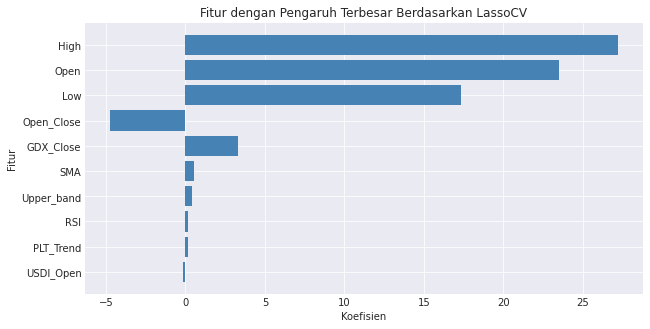

In [ ]:
# Ambil koefisien dari model LassoCV
lasso_coefficients = lasso_clf_feat.coef_

# Susun hasil koefisien dalam DataFrame
coef_df = pd.DataFrame({
    'Fitur': X_train.columns,
    'Koefisien': lasso_coefficients
})

# Urutkan fitur berdasarkan besarnya pengaruh (nilai absolut dari koefisien)
coef_df = coef_df.reindex(coef_df['Koefisien'].abs().sort_values(ascending=False).index)

# Tampilkan 5 fitur paling berpengaruh
print(coef_df.head(5))

# Visualisasi fitur paling berpengaruh
plt.figure(figsize=(10, 5))
plt.barh(coef_df['Fitur'][:10], coef_df['Koefisien'][:10], color='steelblue')
plt.xlabel('Koefisien')
plt.ylabel('Fitur')
plt.title('Fitur dengan Pengaruh Terbesar Berdasarkan LassoCV')
plt.gca().invert_yaxis()
plt.show()
